# Интерпретация

In [60]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import lime
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [ ]:
data_path = r'E:\datasets\realestate_ru\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (93455, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,58,1331,91,2012-04-13,10.0,78.44,3,23.131066,13.0,...,0.894947,0.772872,1.309514,0.853183,7.0,25024.299281,36,0.0,97865,27728
1,Город,75,1677,91,2013-09-16,2.0,34.15,1,14.090185,13.0,...,1.063211,0.840130,-999.000000,1.147596,0.0,18477.300271,372,32413.0,97865,70661
2,Пригород,48,316,10,2014-07-31,17.0,59.85,2,19.453795,13.0,...,0.832622,-999.000000,-999.000000,0.905435,1.0,17441.013879,336,8977.0,97865,12638
3,Пригород,48,1409,91,2012-12-30,12.0,67.53,2,13.178136,13.0,...,-999.000000,1.322121,-999.000000,1.263878,0.0,17019.139763,154,32413.0,97865,70661
4,Пригород,48,1590,91,2014-06-20,5.0,58.13,2,20.691770,13.0,...,0.825295,0.996629,-999.000000,1.024595,2.0,17132.394908,154,32413.0,97865,12638


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

data_path = r'Z:\it\spbu_ml_2026\data\hw_interpretation\data.csv'

data = pd.read_csv(data_path, sep=',')
data = data.dropna()
X, y = data.drop('price_target', axis=1), data['price_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def transform_date(df):
    df = df.copy()
    dt = pd.to_datetime(df['agreement_date'])
    return pd.DataFrame({
        'agreement_year': dt.dt.year,
        'agreement_month': dt.dt.month,
        'agreement_quarter': dt.dt.quarter,
        'agreement_dayofweek': dt.dt.dayofweek
    }, index=df.index)

date_transformer = FunctionTransformer(transform_date, validate=False)

numeric_features: list = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('interior_cat')
numeric_features.remove('class_cat')

cat_features: list = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
cat_features.remove('agreement_date')
cat_features.append('interior_cat')
cat_features.append('class_cat')
preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('date', date_transformer, ['agreement_date'])
    ]
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('date', date_transformer, ['agreement_date'])
    ]
)

X_train_no_scale = preprocessor_no_scale.fit_transform(X_train)
X_test_no_scale = preprocessor_no_scale.transform(X_test)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

models = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "GBR": GradientBoostingRegressor(max_depth=5, random_state=42),
}

def evaluate(model, X_train, X_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, preds)
    
    return mse, rmse, mape

results = {}

for name, model in models.items():
    results[f"{name}_no_scale"] = evaluate(model, X_train_no_scale, X_test_no_scale)
    results[f"{name}_scaled"] = evaluate(model, X_train_scaled, X_test_scaled)

for name, (mse, rmse, mape) in results.items():
    print(f"{name}:")
    print(f"MSE={mse:.4f}")
    print(f"RMSE={rmse:.4f}")
    print(f"MAPE={mape:.4f}")

Linear_no_scale:
MSE=12319894.2487
RMSE=3509.9707
MAPE=0.0812
Linear_scaled:
MSE=12319894.2487
RMSE=3509.9707
MAPE=0.0812
Lasso_no_scale:
MSE=12754661.7921
RMSE=3571.3669
MAPE=0.0848
Lasso_scaled:
MSE=12639498.3781
RMSE=3555.2072
MAPE=0.0835
GBR_no_scale:
MSE=3088873.7985
RMSE=1757.5192
MAPE=0.0394
GBR_scaled:
MSE=3100522.1895
RMSE=1760.8300
MAPE=0.0394


Очевидно, что на GBR скейлинг данных не влияет, тк под капотом там деревья решений, которые делают сплит по одному признаку. Там важен порядок, пространство не играет роли.
А в линейных моделях скейлинг важен, потому что каждый признак вносит вклад и признаки с большими значениями будут вносить больший.
Больше подходит MSE или RMSE - это стандартная метрика и она сильнее штрафует за сильные отклронения


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [27]:
from sklearn.preprocessing import MinMaxScaler

preprocessor_std = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('date', date_transformer, ['agreement_date'])
])

preprocessor_minmax = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('date', date_transformer, ['agreement_date'])
])

X_train_std = preprocessor_std.fit_transform(X_train)
X_train_mm = preprocessor_minmax.fit_transform(X_train)

def get_feature_names(preprocessor):
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
    date_names = np.array([
        'agreement_year',
        'agreement_month',
        'agreement_quarter',
        'agreement_dayofweek'
    ])
    return np.concatenate([numeric_features, cat_names, date_names])

feature_names = get_feature_names(preprocessor_std)

for name, model in models.items():
    if name == "GBR":
        continue

    model.fit(X_train_std, y_train)
    coef_std = model.coef_

    df_std = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coef_std)
    }).sort_values("importance", ascending=False).head(10)

    print(f"\n{name} | StandardScaler")
    print(df_std)



    model.fit(X_train_mm, y_train)
    coef_mm = model.coef_

    df_mm = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coef_mm)
    }).sort_values("importance", ascending=False).head(10)

    print(f"\n{name} | MinMaxScaler")
    print(df_mm)

gbr_model = models["GBR"]
gbr_model.fit(X_train_std, y_train)

importances = gbr_model.feature_importances_
df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(df.head(10))

gbr_model = models["GBR"]
gbr_model.fit(X_train_mm, y_train)

importances = gbr_model.feature_importances_
df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(df.head(10))


Linear | StandardScaler
                                              feature    importance
70  location_public_transport_platform_w_mean_dist...  1.640000e+06
54              location_shop_product_w_mean_distance  1.013072e+06
57          location_highway_crossing_w_mean_distance  6.265013e+05
91                                     class_cat_2581  2.244566e+04
93                                    class_cat_97865  1.349962e+04
35                           location_std_levels_mean  1.100017e+04
45                location_shop_other_w_mean_distance  9.445576e+03
92                                    class_cat_27353  8.946037e+03
86                                interior_cat_1280.0  4.187713e+03
63                  location_pop_shop_w_mean_distance  3.905659e+03

Linear | MinMaxScaler
                                              feature    importance
70  location_public_transport_platform_w_mean_dist...  1.761448e+07
54              location_shop_product_w_mean_distance  1.088216e+07


Скейлеры влияют только у лассо регрессии, так как там регуляризация зависит от масштаба признака, а разные скейлеры приводят к разным масштабам.  

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [ ]:
data.square.head(30)

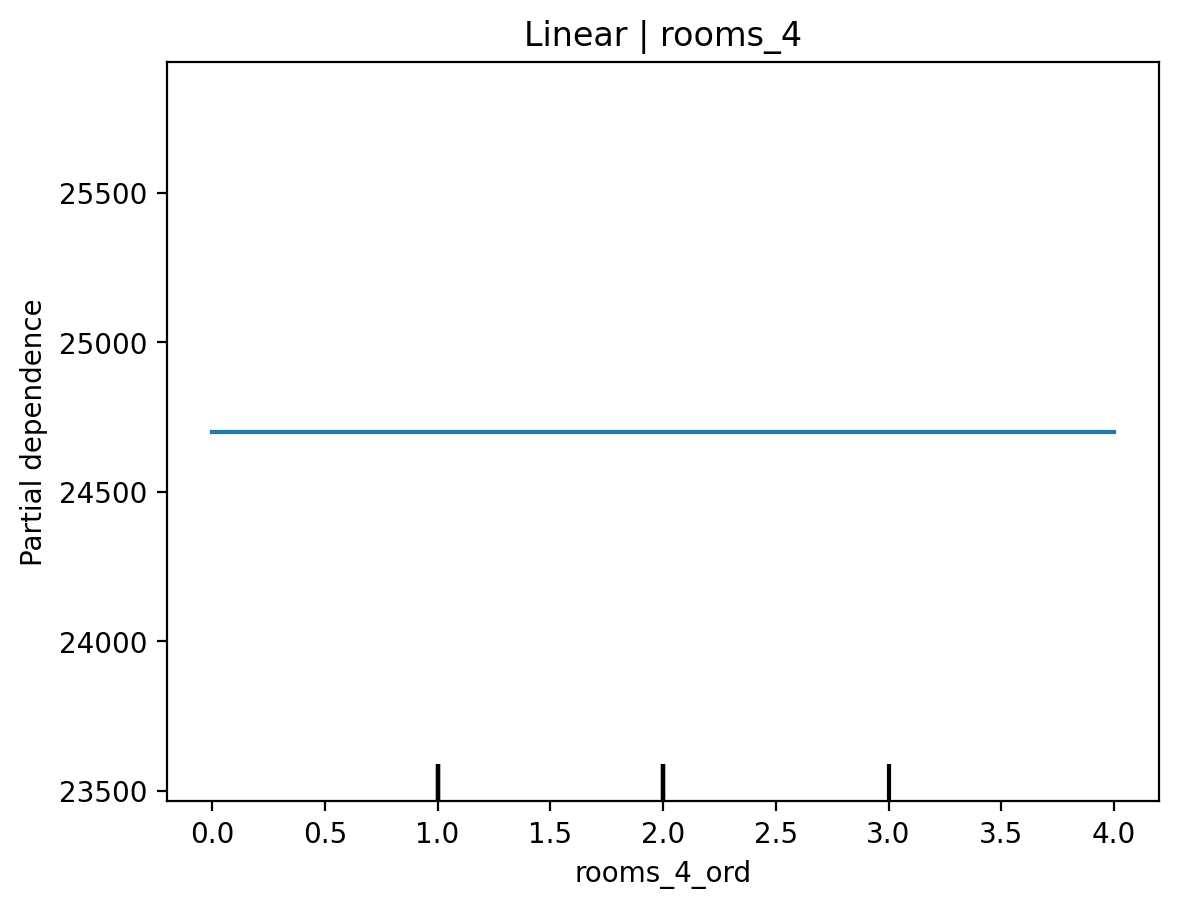

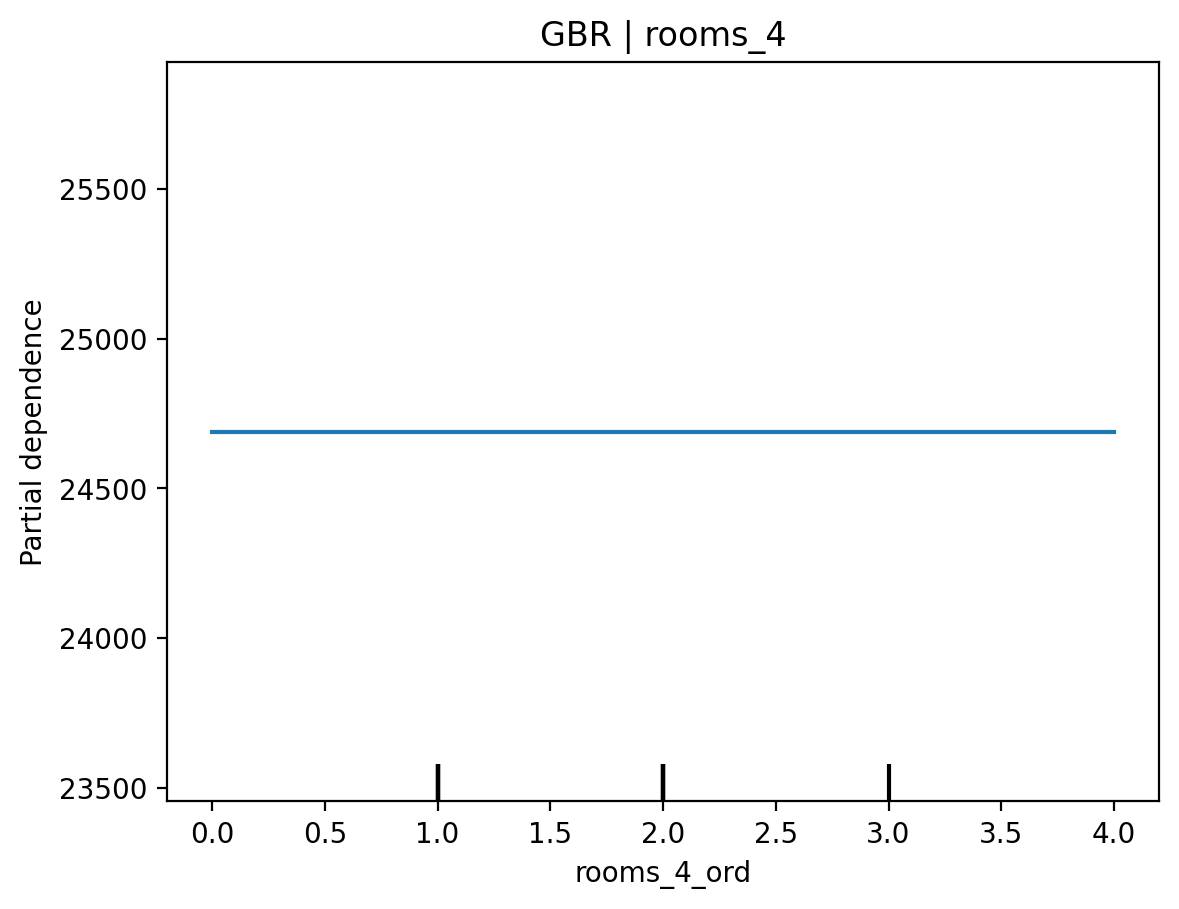

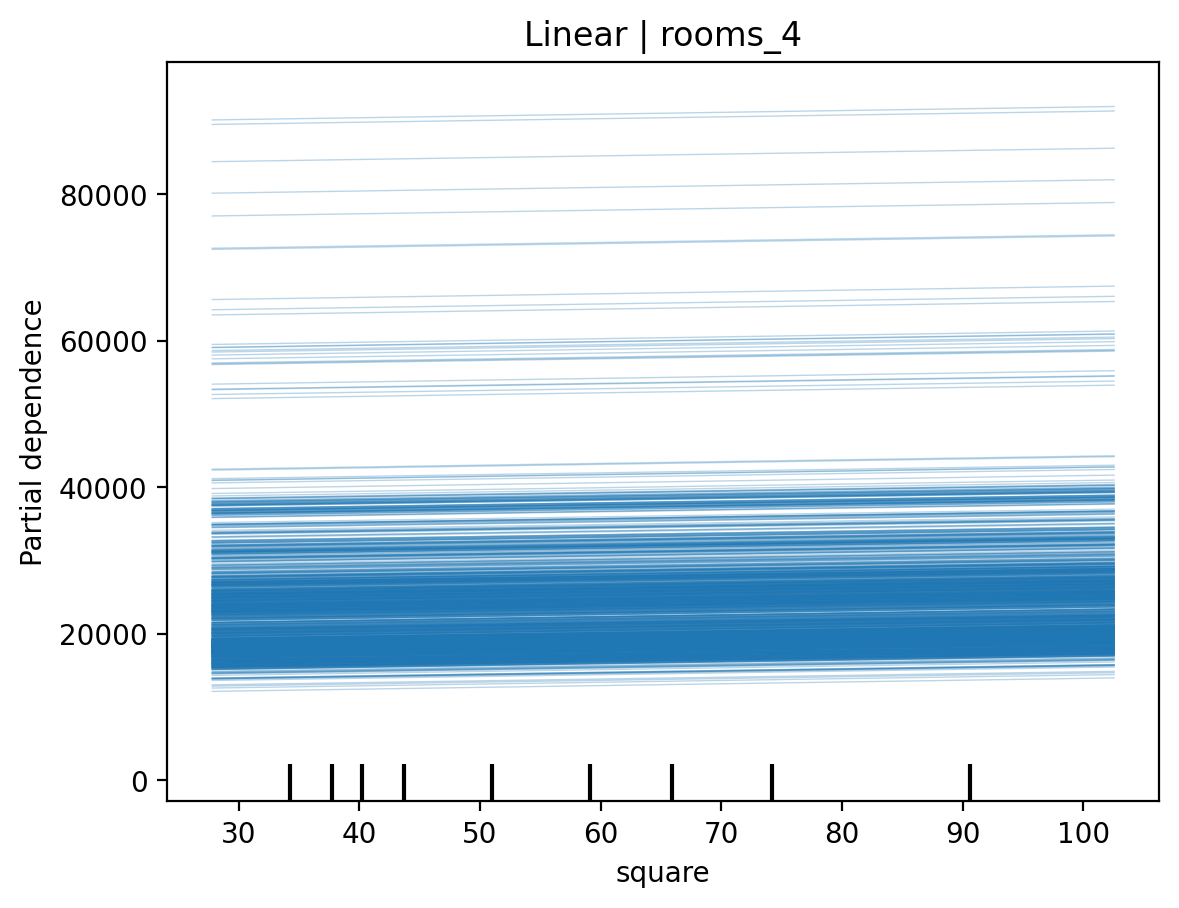

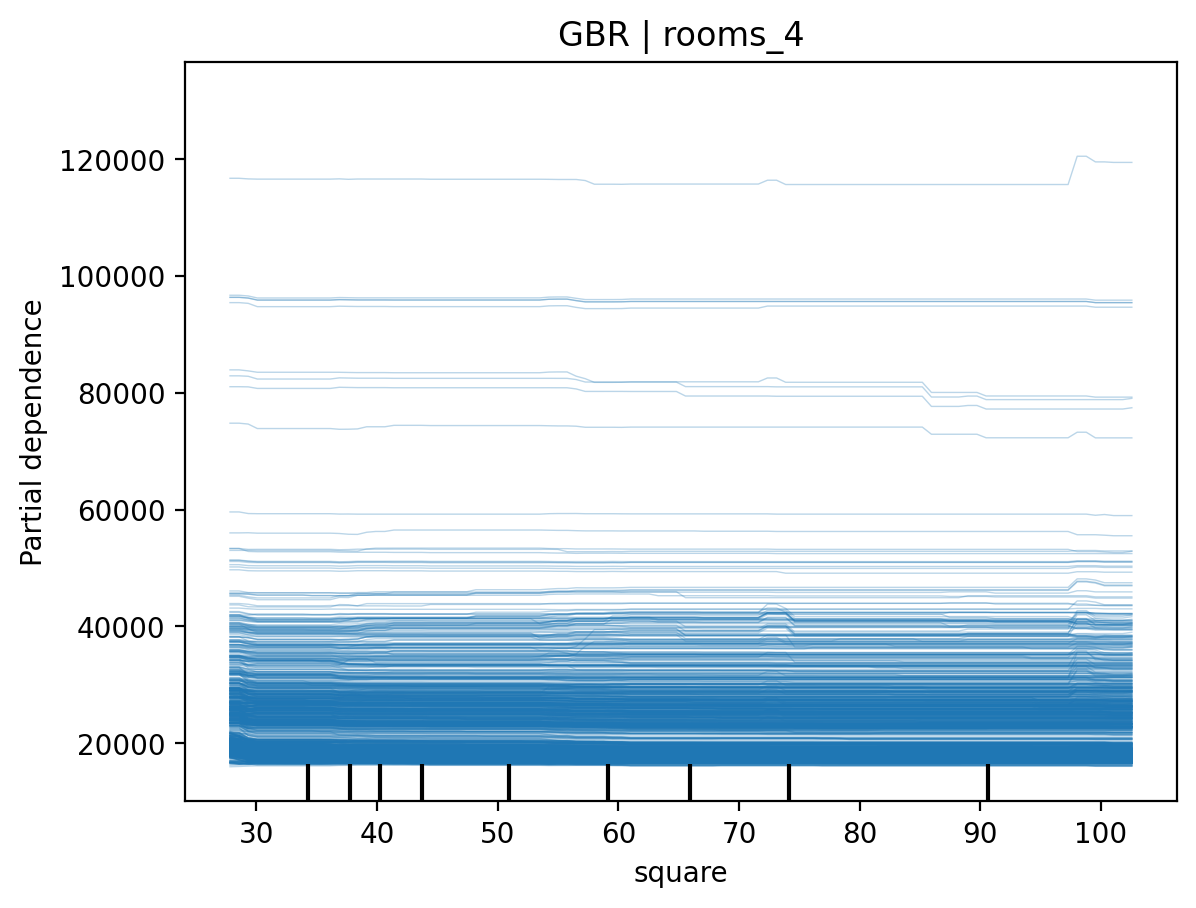

In [46]:
from sklearn.pipeline import Pipeline

mapping = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}
X_train['rooms_4_ord'] = X_train['rooms_4'].map(mapping)
X_test['rooms_4_ord'] = X_test['rooms_4'].map(mapping)

pipe_linear = Pipeline([
    ("prep", preprocessor_minmax),
    ("model", LinearRegression())
])

pipe_gbr = Pipeline([
    ("prep", preprocessor_minmax),
    ("model", GradientBoostingRegressor(max_depth=5, random_state=42))
])

pipe_linear.fit(X_train, y_train)
pipe_gbr.fit(X_train, y_train)

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    pipe_linear,
    X_test,
    features=['rooms_4_ord'],
    kind='average'
)
plt.title("Linear | rooms_4")
plt.show()

PartialDependenceDisplay.from_estimator(
    pipe_gbr,
    X_test,
    features=['rooms_4_ord'],
    kind='average'
)
plt.title("GBR | rooms_4")
plt.show()

PartialDependenceDisplay.from_estimator(
    pipe_linear,
    X_test,
    features=['square'],# надо будет поменять на rooms_4_ord
    kind='individual'
)
plt.title("Linear | rooms_4")
plt.show()

PartialDependenceDisplay.from_estimator(
    pipe_gbr,
    X_test,
    features=['square'], # надо будет поменять на rooms_4_ord
    kind='individual'
)
plt.title("GBR | rooms_4")
plt.show()

Ну тут ничего не роляет.

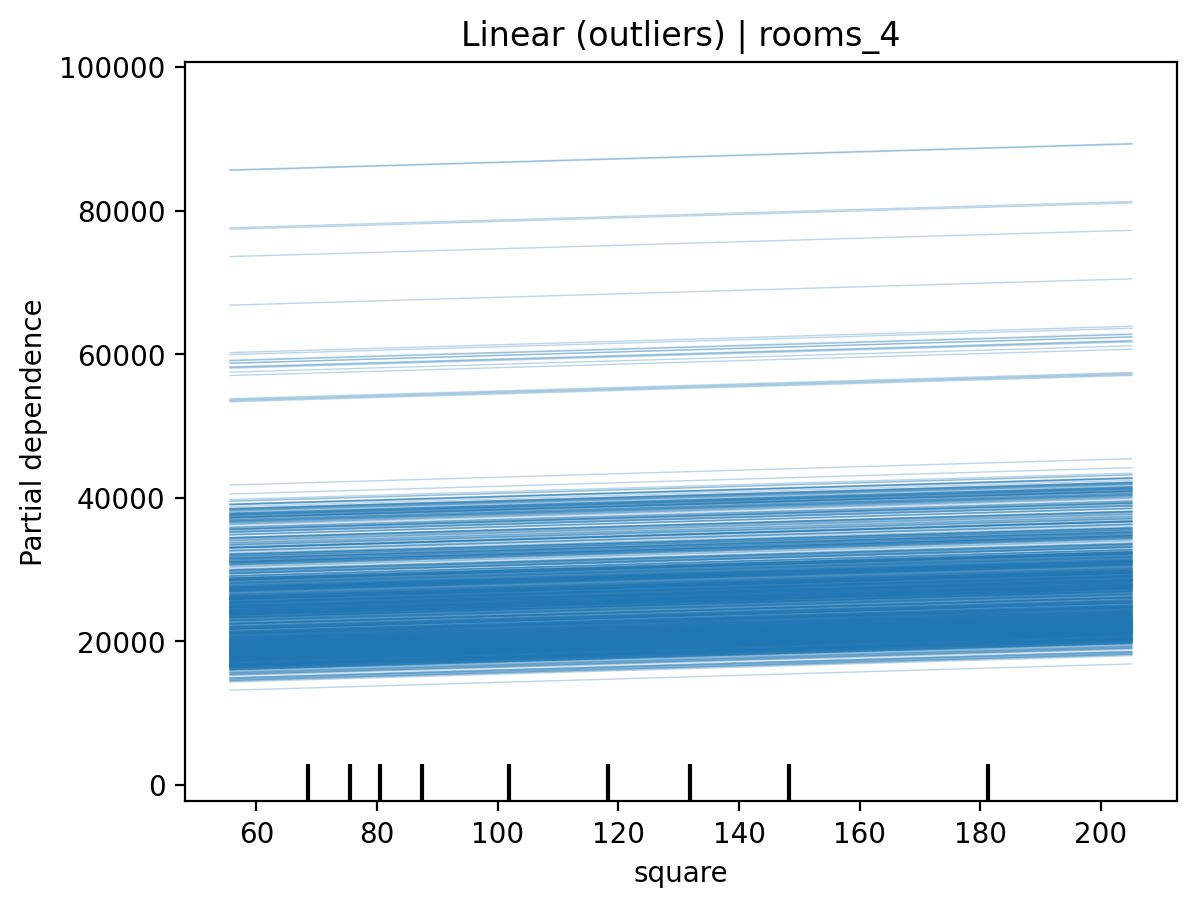

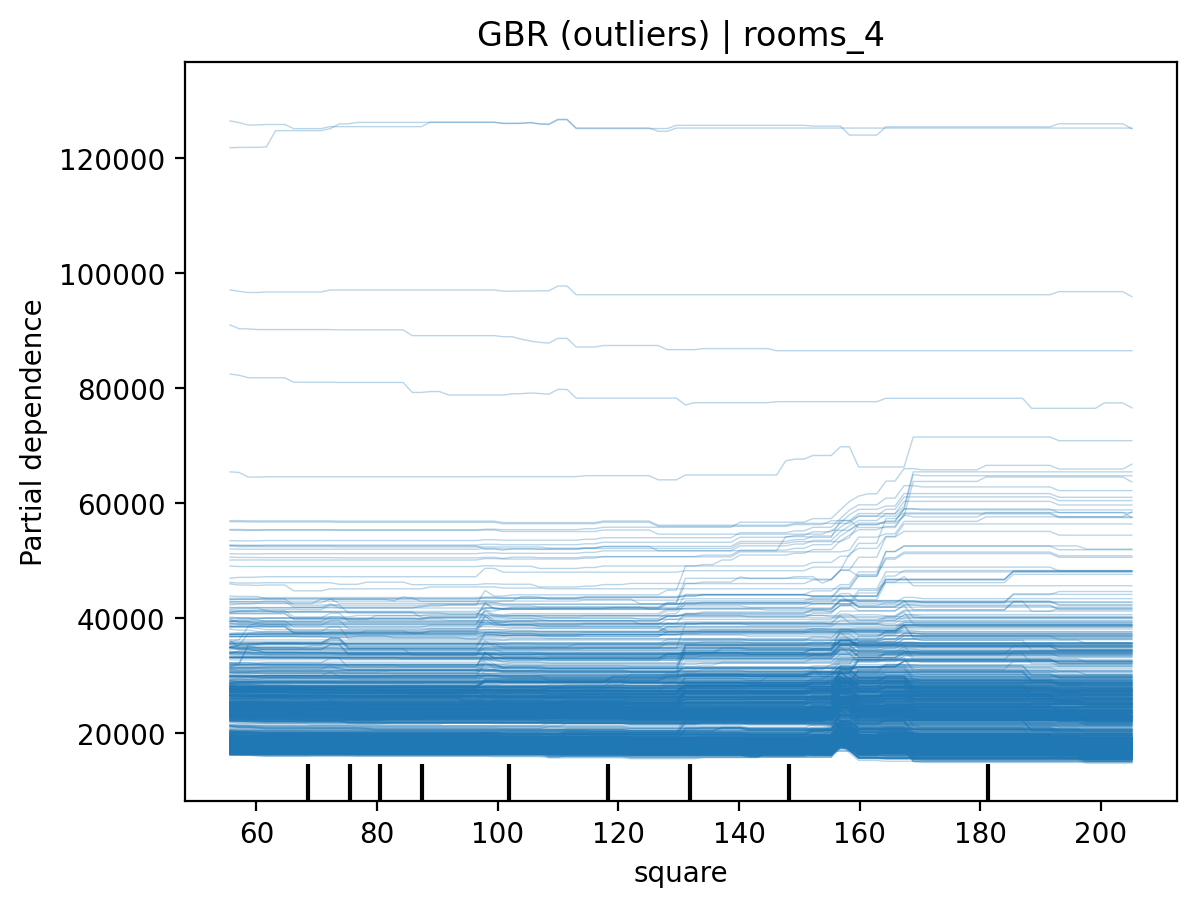

In [45]:
X_test_outliers = X_test.copy()

X_test_outliers['square'] = X_test_outliers['square'] * 2

PartialDependenceDisplay.from_estimator(
    pipe_linear,
    X_test_outliers,
    features=['square'],
    kind='individual'
)
plt.title("Linear (outliers) | rooms_4")
plt.show()

PartialDependenceDisplay.from_estimator(
    pipe_gbr,
    X_test_outliers,
    features=['square'],
    kind='individual'
)
plt.title("GBR (outliers) | rooms_4")
plt.show()

Линейная экстраполирует фичи, дерево начинает схожить с ума

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

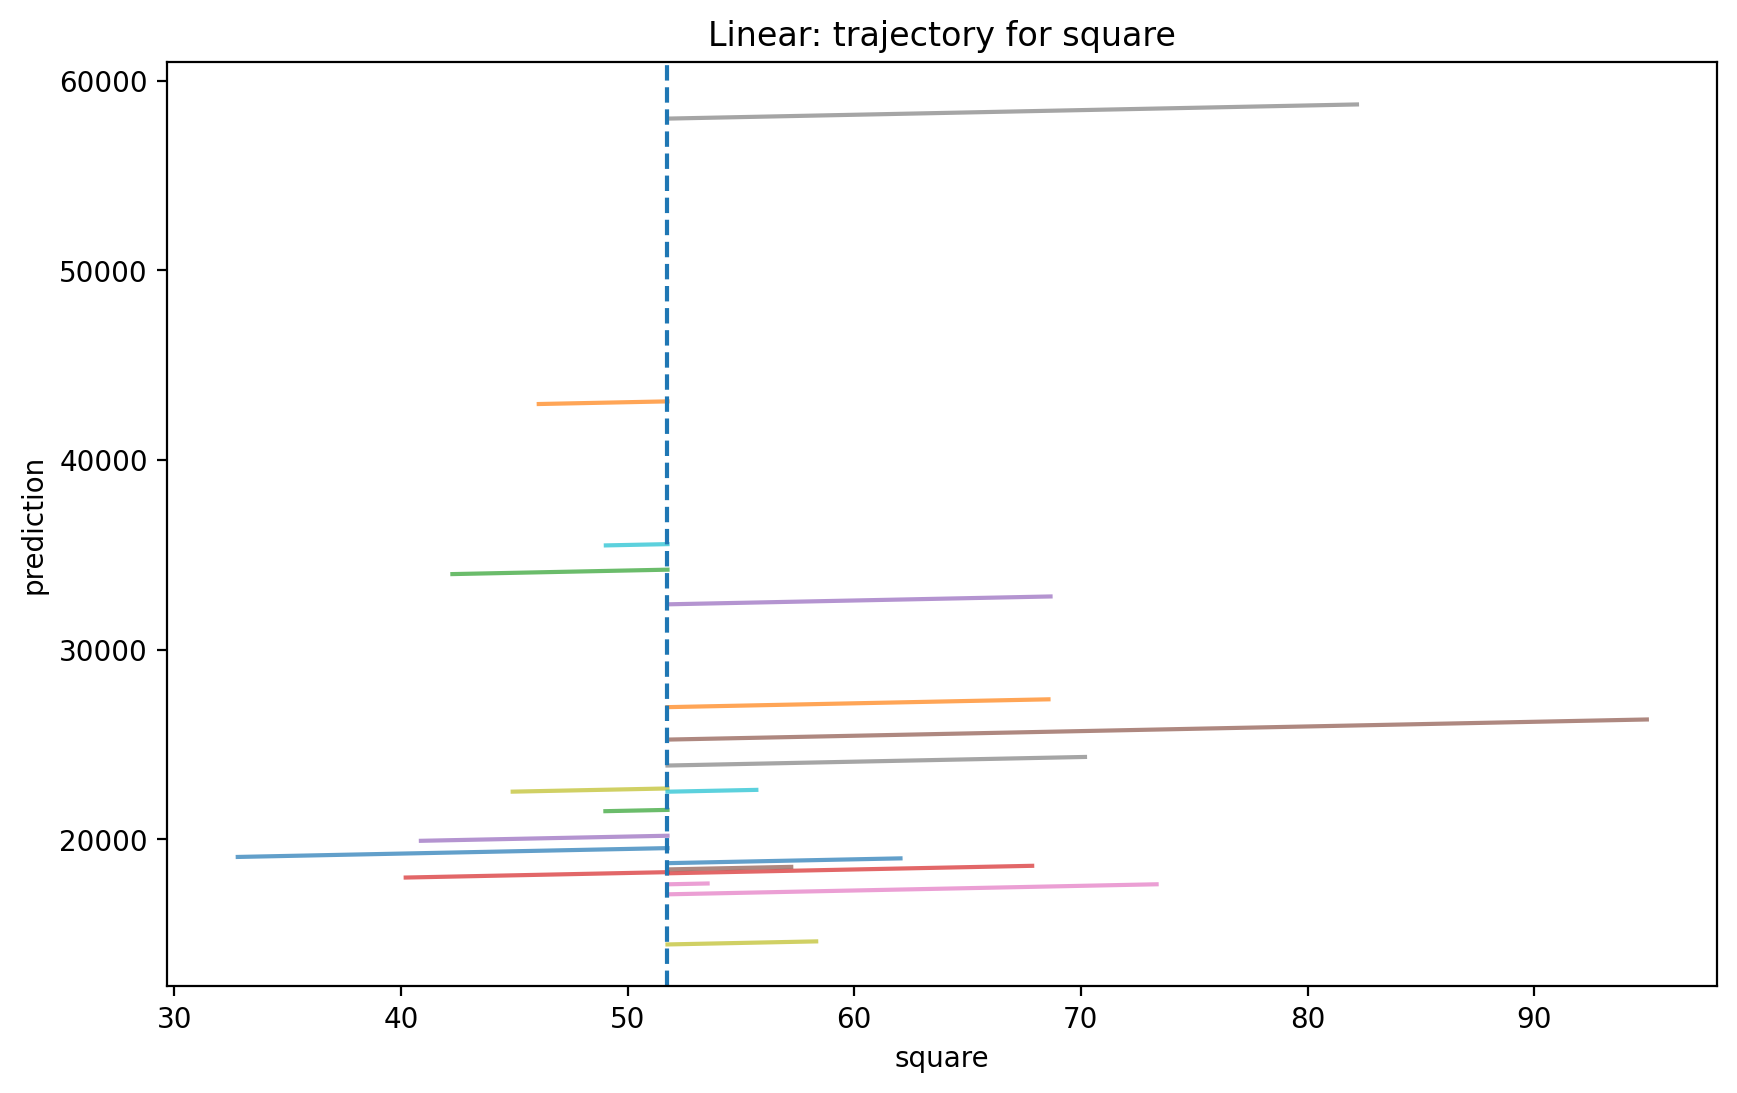

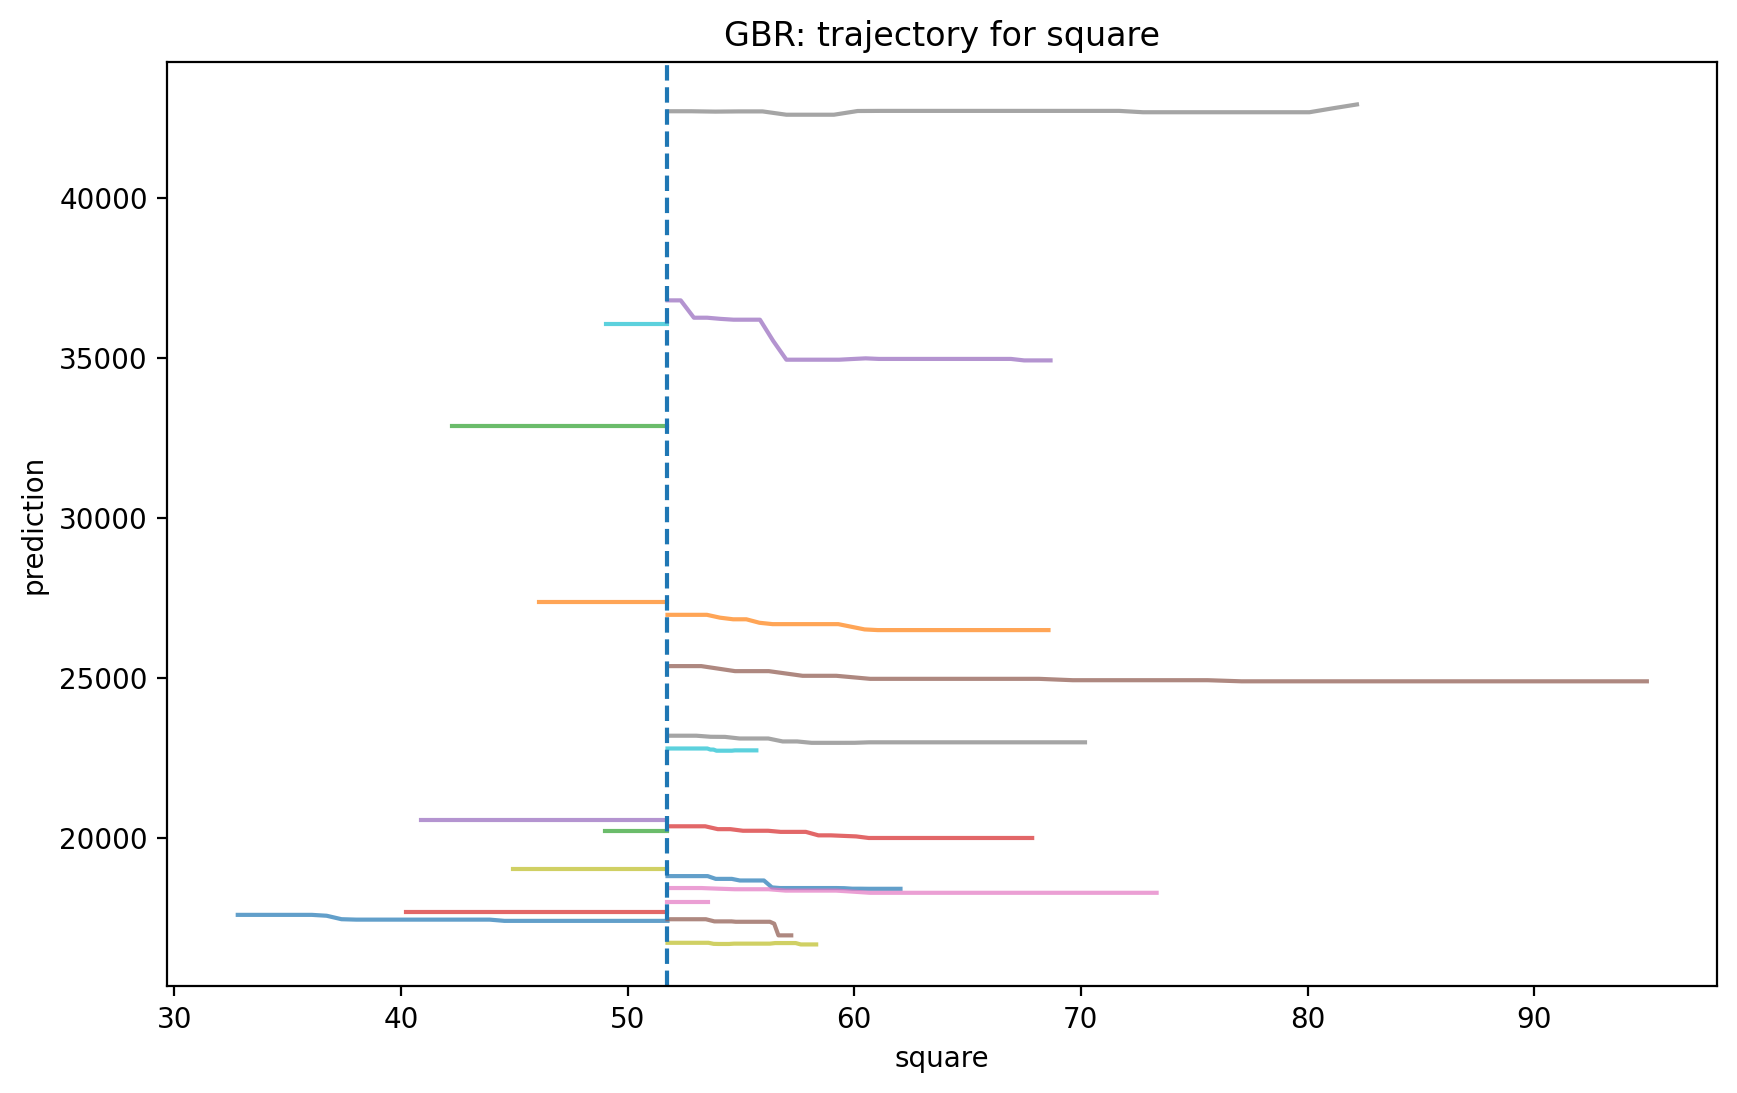

In [ ]:
X_test_20 = X_test.sample(n=20, random_state=42).copy()

feature_1 = 'square'
feature_2 = 'location_logs_count_mean'

base_1 = X_train[feature_1].median()
base_2 = X_train[feature_2].median()

n_steps = 30

def plot_trajectory_for_feature(model, X_subset, feature_name, base_value, model_name, n_steps=30):
    plt.figure(figsize=(10, 6))
    
    for idx in X_subset.index:
        x_obj = X_subset.loc[[idx]].copy()
        current_value = x_obj.iloc[0][feature_name]
        
        inter = np.linspace(current_value, base_value, n_steps)
        preds = []
        
        for val in inter:
            x_mod = x_obj.copy()
            x_mod.at[idx, feature_name] = val
            pred = model.predict(x_mod)[0]
            preds.append(pred)
        
        plt.plot(inter, preds, alpha=0.7)
    
    plt.axvline(base_value, linestyle='--')
    plt.xlabel(feature_name)
    plt.ylabel('prediction')
    plt.title(f'{model_name}: trajectory for {feature_name}')
    plt.show()

plot_trajectory_for_feature(
    pipe_linear, X_test_20, feature_1, base_1, "Linear", n_steps=n_steps
)

plot_trajectory_for_feature(
    pipe_gbr, X_test_20, feature_1, base_1, "GBR", n_steps=n_steps
)

У линейной линейно, у гбр ступенчато и причем разные обьекты по разному влияют

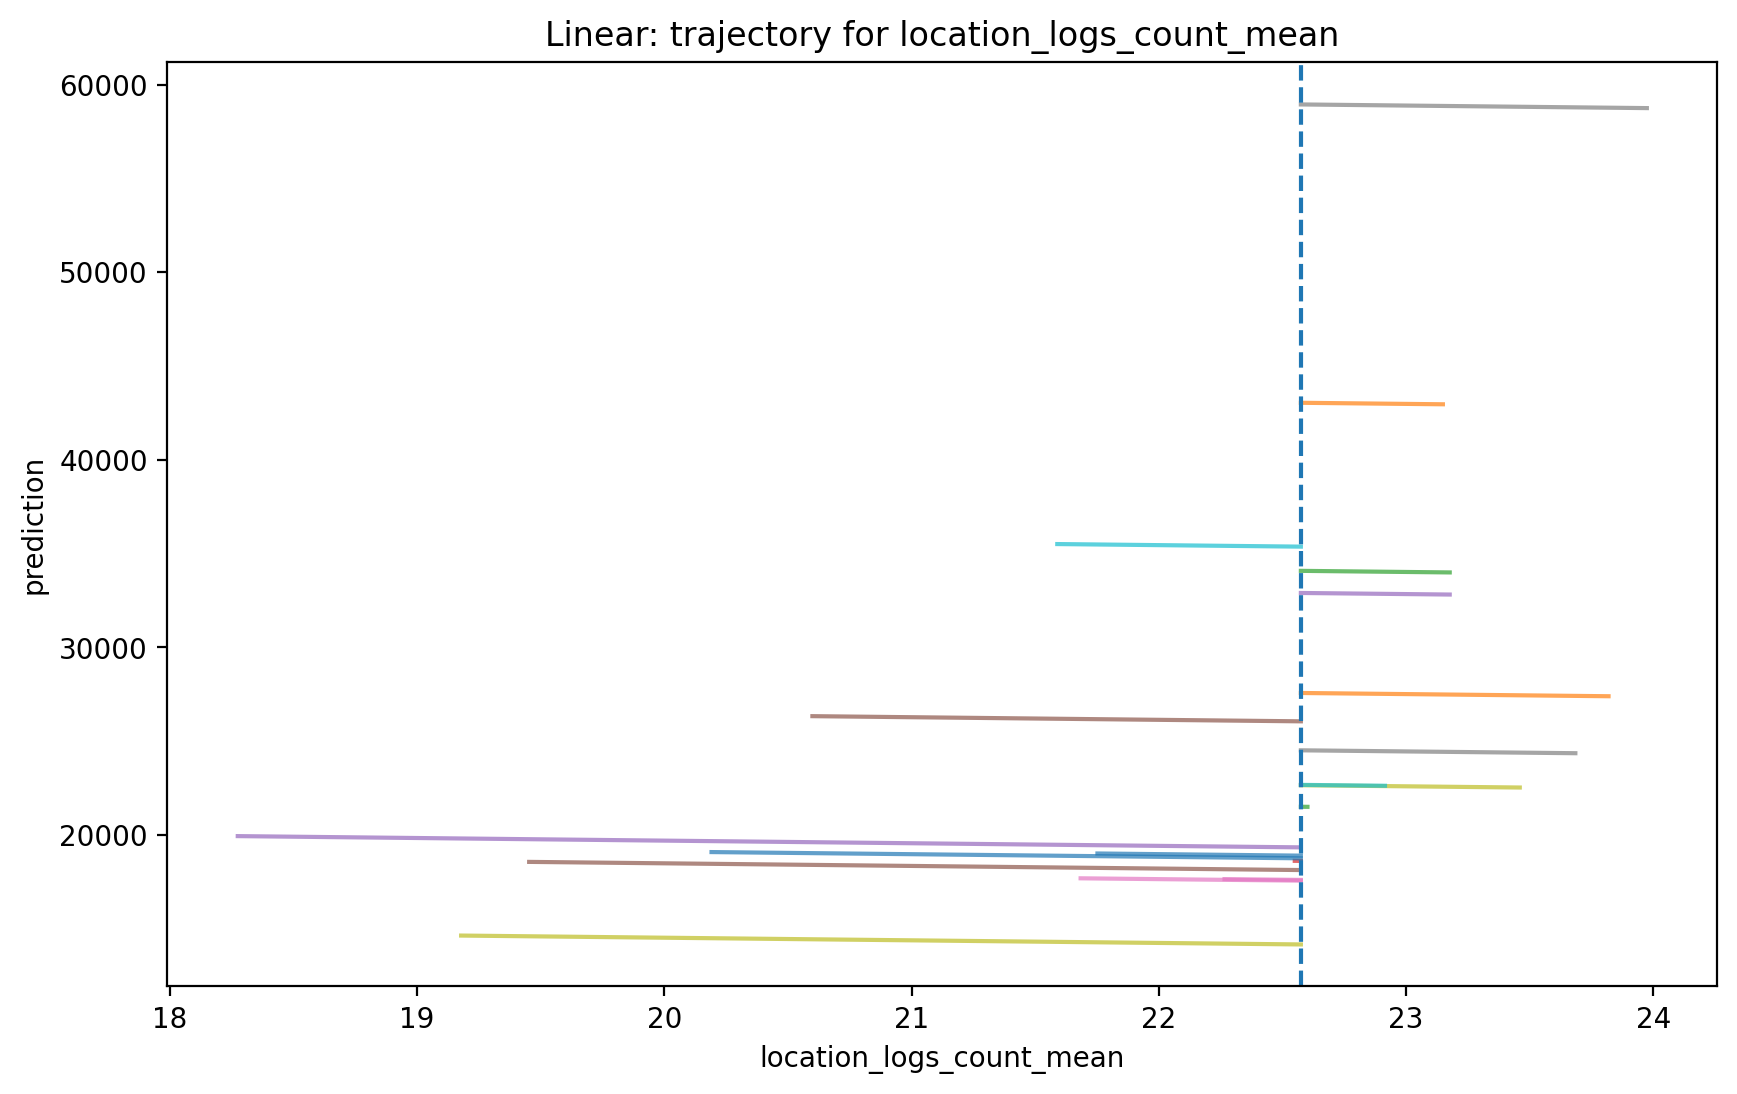

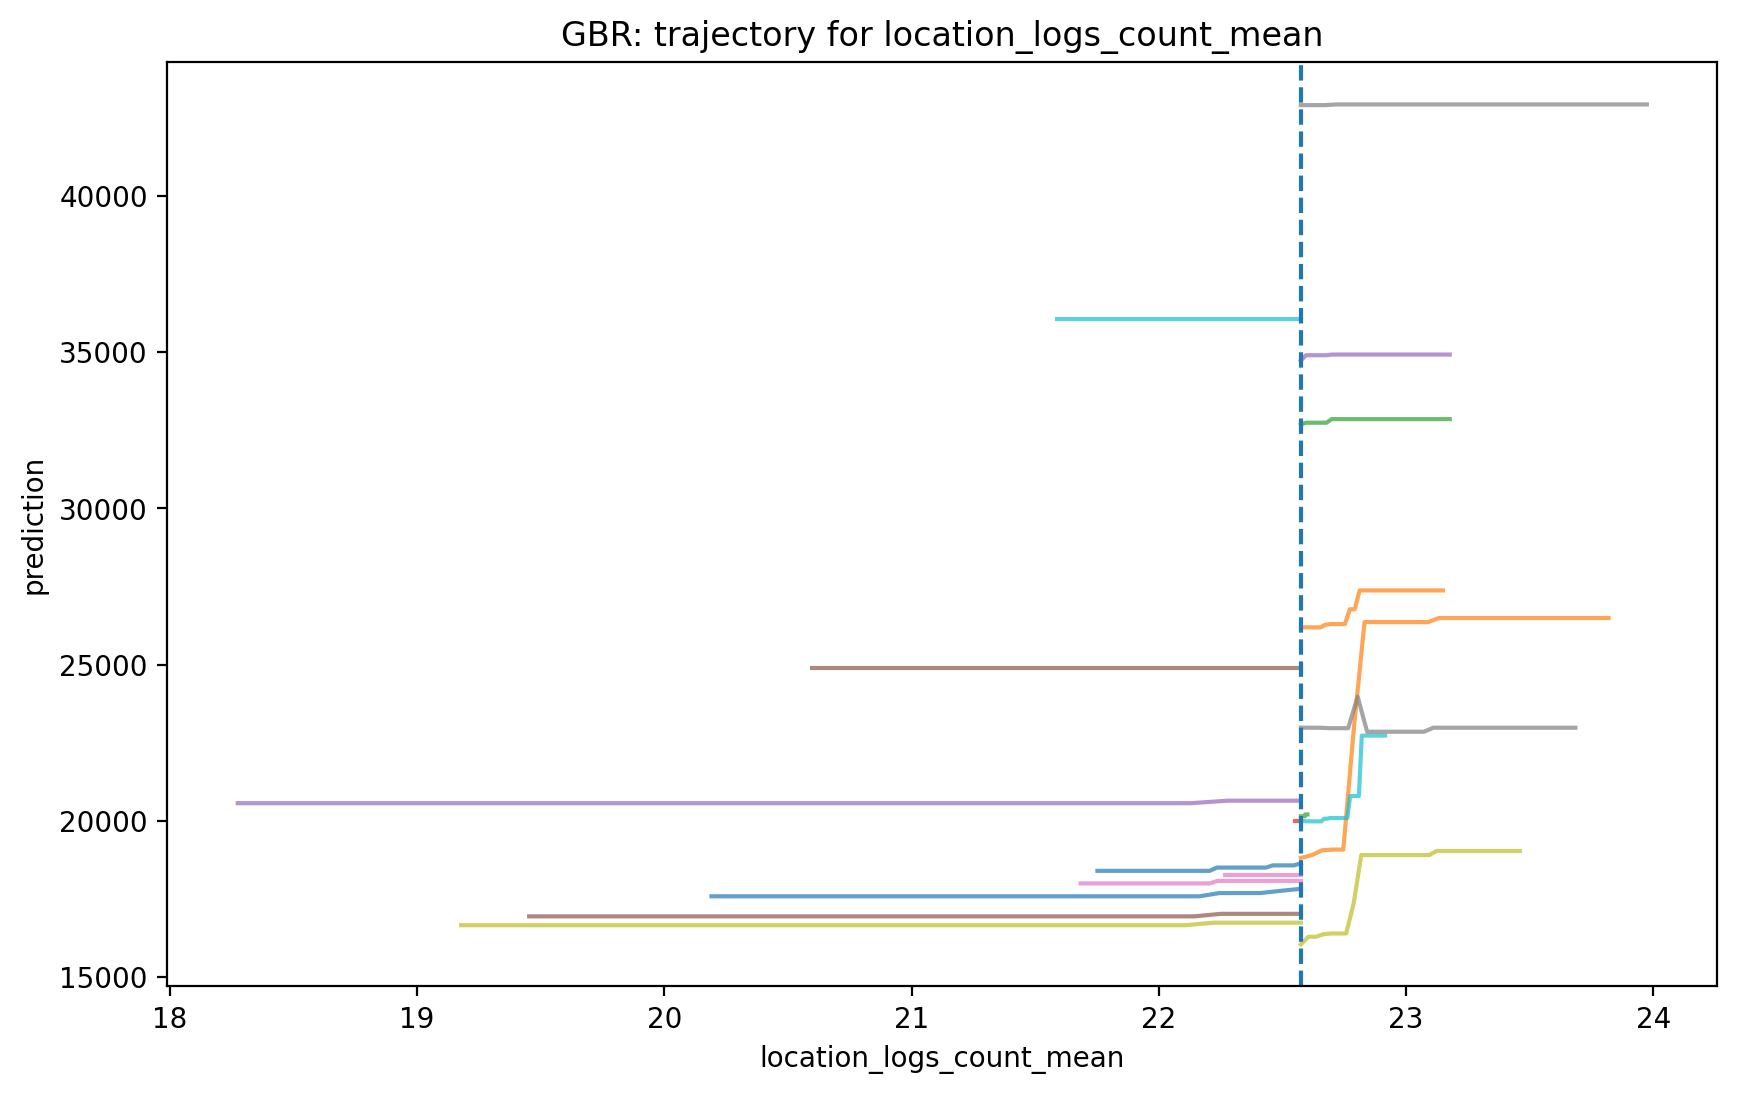

In [49]:
plot_trajectory_for_feature(
    pipe_linear, X_test_20, feature_2, base_2, "Linear", n_steps=n_steps
)

plot_trajectory_for_feature(
    pipe_gbr, X_test_20, feature_2, base_2, "GBR", n_steps=n_steps
)

Аналогичная ситуация.

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [52]:
from PyALE import ale
import matplotlib.pyplot as plt

feature_name = 'square'

ale_lin_square = ale(
    X=X_train,
    model=pipe_linear,
    feature=[feature_name],
    grid_size=20,
    include_CI=True,
    C=0.95,
    plot=False
)

ale_gbr_square = ale(
    X=X_train,
    model=pipe_gbr,
    feature=[feature_name],
    grid_size=20,
    include_CI=True,
    C=0.95,
    plot=False
)

print(ale_lin_square.head())
print(ale_gbr_square.head())

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


                eff    size  lowerCI_95%  upperCI_95%
square                                               
18.66  -1121.277433     0.0          NaN          NaN
27.42   -906.303892  1184.0  -906.303892  -906.303892
34.17   -740.656471  1183.0  -740.656471  -740.656471
36.13   -692.557369  1187.0  -692.557369  -692.557369
37.72   -653.538198  1182.0  -653.538198  -653.538198
                eff    size  lowerCI_95%  upperCI_95%
square                                               
18.66   1120.950049     0.0          NaN          NaN
27.42    806.096509  1184.0   790.273474   821.919545
34.17     48.351318  1183.0    22.960296    73.742341
36.13     49.524043  1187.0    47.223463    51.824624
37.72    -65.160887  1182.0   -70.784046   -59.537729


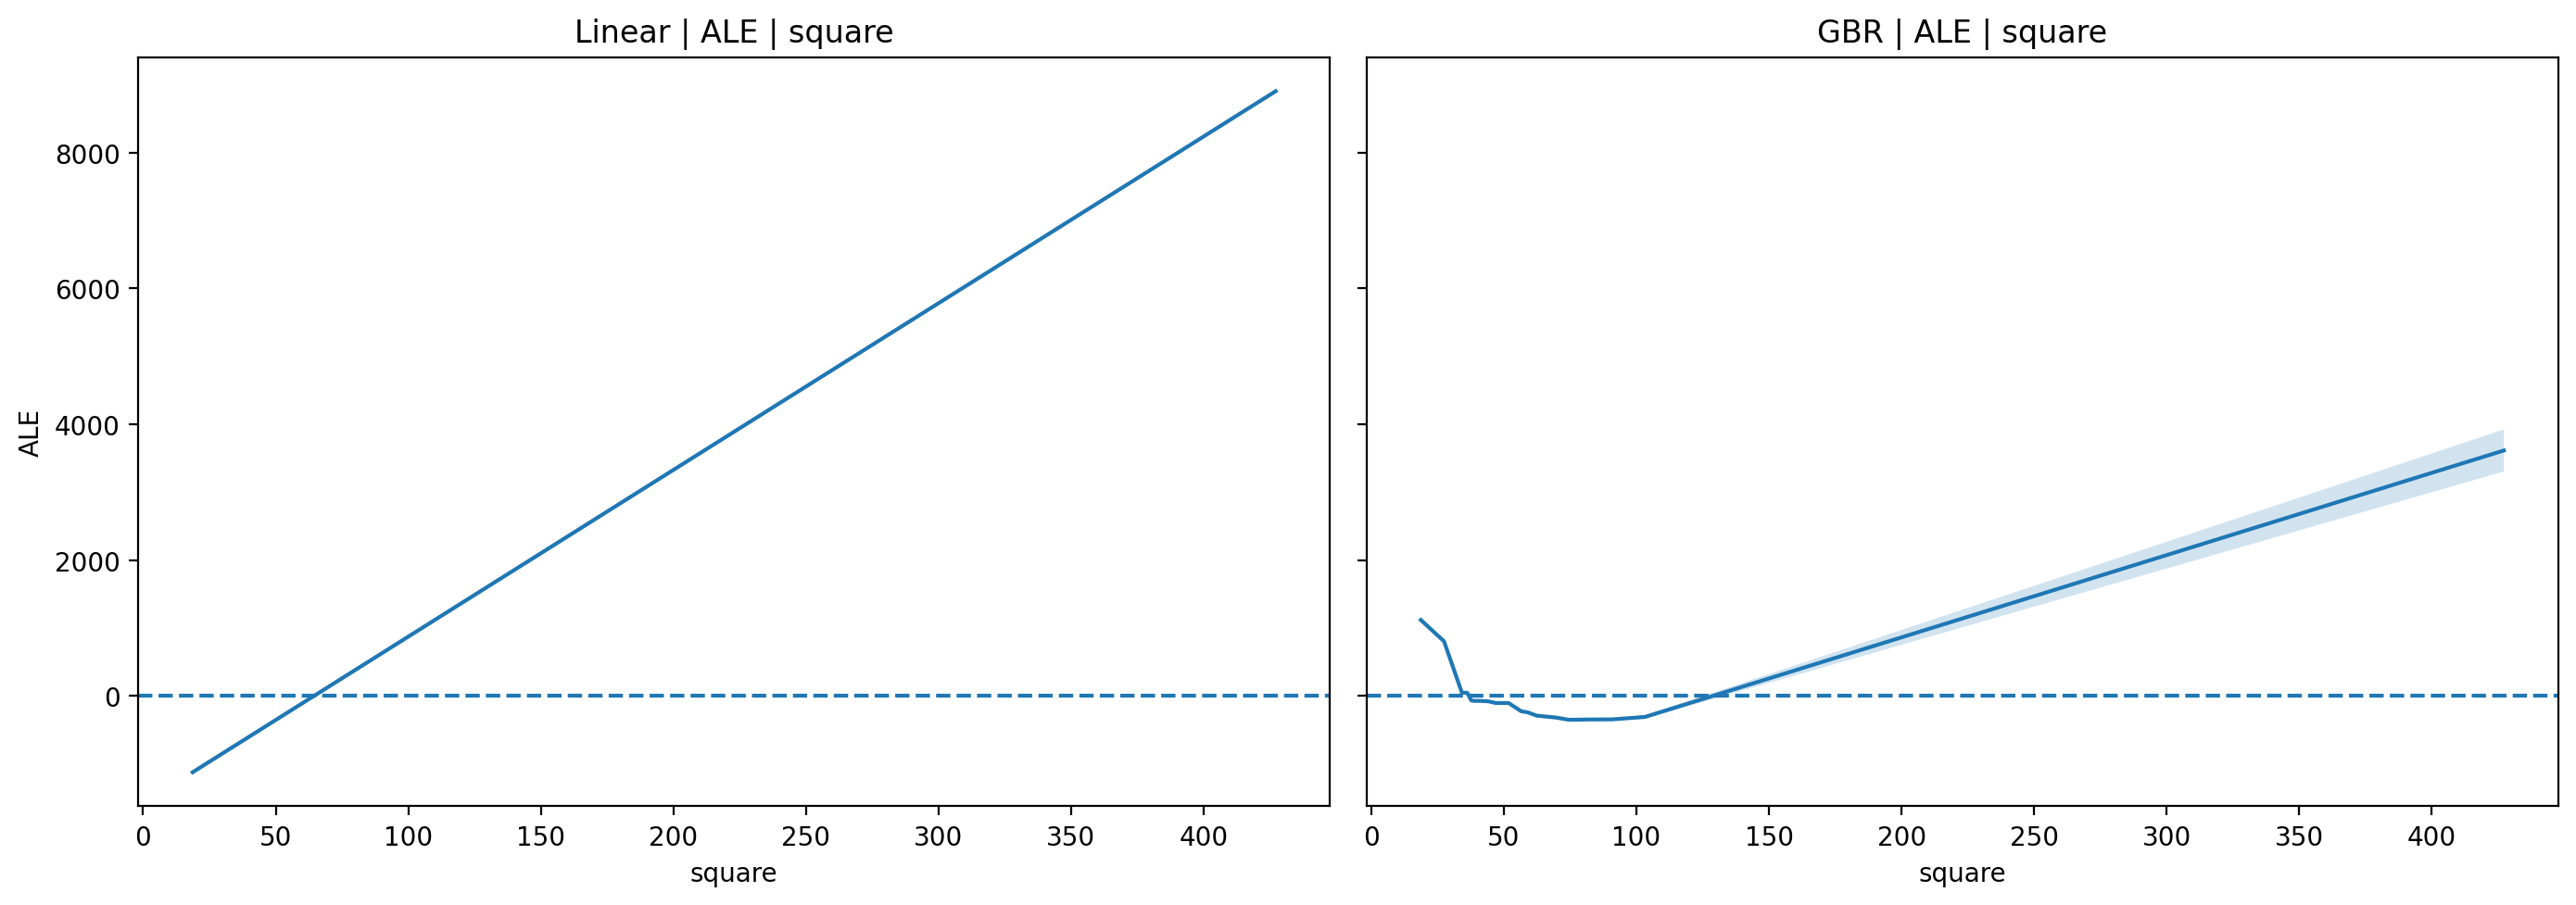

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(ale_lin_square.index, ale_lin_square['eff'], label='ALE')
axes[0].fill_between(
    ale_lin_square.index,
    ale_lin_square['lowerCI_95%'],
    ale_lin_square['upperCI_95%'],
    alpha=0.2
)
axes[0].axhline(0, linestyle='--')
axes[0].set_title('Linear | ALE | square')
axes[0].set_xlabel('square')
axes[0].set_ylabel('ALE')

axes[1].plot(ale_gbr_square.index, ale_gbr_square['eff'], label='ALE')
axes[1].fill_between(
    ale_gbr_square.index,
    ale_gbr_square['lowerCI_95%'],
    ale_gbr_square['upperCI_95%'],
    alpha=0.2
)
axes[1].axhline(0, linestyle='--')
axes[1].set_title('GBR | ALE | square')
axes[1].set_xlabel('square')

plt.tight_layout()
plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [55]:
def compute_perm_importance(model, X, y, n_repeats):
    perm = permutation_importance(
        model,
        X,
        y,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )
    
    df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return df

repeats_list = [5, 10, 20, 50]

results_linear = {}
results_gbr = {}

for r in repeats_list:
    results_linear[r] = compute_perm_importance(pipe_linear, X_test, y_test, r)
    results_gbr[r] = compute_perm_importance(pipe_gbr, X_test, y_test, r)

for r in repeats_list:
    print(f"\nLinear | n_repeats={r}")
    print(results_linear[r].head(10))

    print(f"\nGBR | n_repeats={r}")
    print(results_gbr[r].head(10))


Linear | n_repeats=5
                                              feature  importance_mean  \
73  location_public_transport_platform_w_mean_dist...     54075.433361   
57              location_shop_product_w_mean_distance     20633.719831   
60          location_highway_crossing_w_mean_distance      7890.999612   
38                           location_std_levels_mean         2.409736   
48                location_shop_other_w_mean_distance         1.763615   
80                                          class_cat         0.621205   
66                  location_pop_shop_w_mean_distance         0.295247   
44             location_public_transport_platform_cnt         0.229808   
12                       location_hds_ratio_mean_mean         0.204096   
71          location_amenity_pharmacy_w_mean_distance         0.170507   

    importance_std  
73      513.281586  
57      196.308274  
60       75.211668  
38        0.008160  
48        0.006682  
80        0.011460  
66        0.0033

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

Base MAPE: 0.03900230883054777


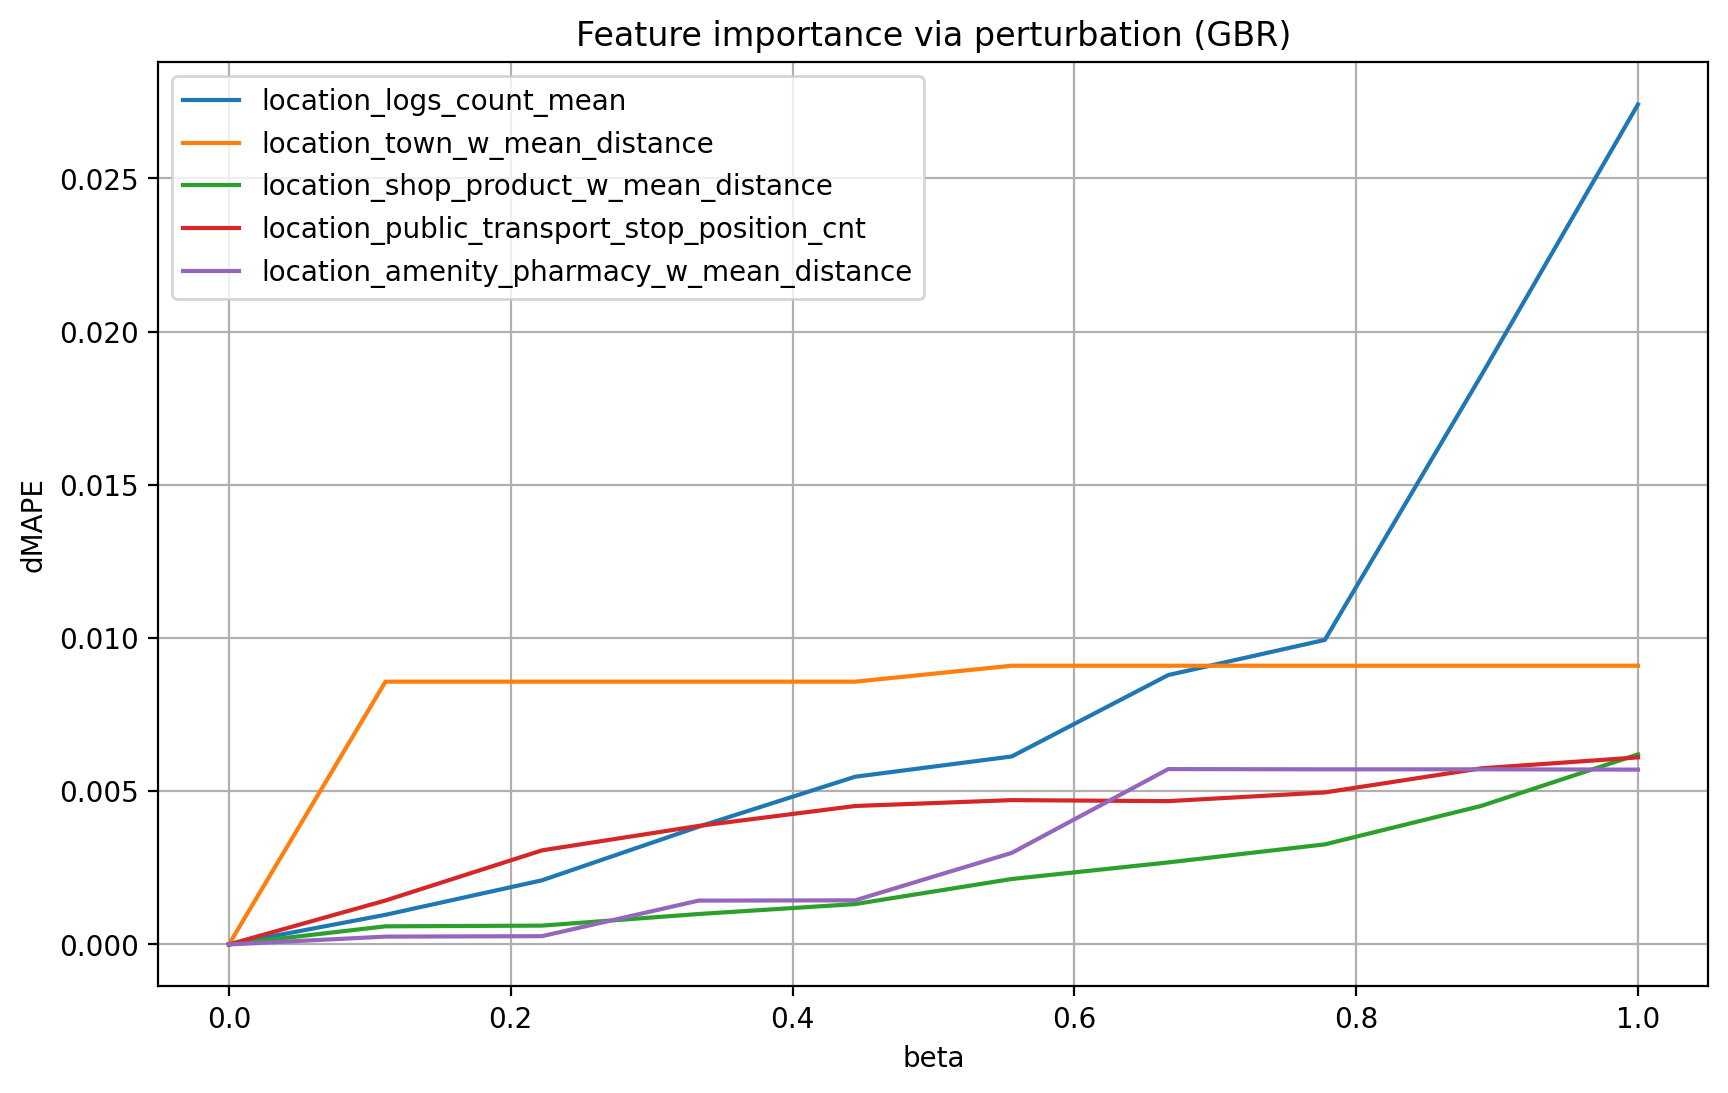

                                        feature  perm_importance
80                                    class_cat         1.030901
8                      location_logs_count_mean         0.186075
59             location_railway_w_mean_distance         0.028052
61  location_public_transport_stop_position_cnt         0.027325
32                location_town_w_mean_distance         0.020471
1                                  district_cat         0.013156
81                                    stage_cat         0.011572
4                                agreement_date         0.008261
78                                  hc_name_cat         0.007360
57        location_shop_product_w_mean_distance         0.006501


In [58]:
base_pred = pipe_gbr.predict(X_test)
base_mape = mean_absolute_percentage_error(y_test, base_pred)

print("Base MAPE:", base_mape)

medians = X_train[numeric_features].median()

def feature_importance_beta(model, X_test, y_test, medians, feature, betas):
    results = []

    for beta in betas:
        X_mod = X_test.copy()

        X_mod[feature] = (1 - beta) * X_mod[feature] + beta * medians[feature]

        preds = model.predict(X_mod)
        mape = mean_absolute_percentage_error(y_test, preds)

        results.append(mape)

    return np.array(results)

betas = np.linspace(0, 1, 10)

importance_beta = {}

for col in numeric_features:
    mape_path = feature_importance_beta(
        pipe_gbr, X_test, y_test, medians, col, betas
    )

    importance_beta[col] = mape_path - base_mape

final_importance = {
    col: importance_beta[col][-1] for col in numeric_features
}

top_features = sorted(final_importance, key=final_importance.get, reverse=True)[:5]

plt.figure(figsize=(10, 6))

for col in top_features:
    plt.plot(betas, importance_beta[col], label=col)

plt.xlabel("beta")
plt.ylabel("dMAPE")
plt.title("Feature importance via perturbation (GBR)")
plt.legend()
plt.grid(True)
plt.show()

perm = permutation_importance(
    pipe_gbr,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "perm_importance": perm.importances_mean
}).sort_values("perm_importance", ascending=False)

print(perm_df.head(10))

location_logs_count_mean совпадает и там и там. Пермутейшн все лормает за раз и чутка завышает важности

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 




=== Object 13093 ===
Prediction: 18485.269722258086
[('location_motel_cnt <= 0.00', -10635.188270526143), ('24.00 < location_max_levels_max <= 25.00', -5931.498330856795), ('location_public_transport_stop_position_cnt <= 9.00', -3467.8191778886603), ('location_hds_ratio_mean_mean > 1.33', 2510.6731026189873), ('21.52 < location_logs_count_mean <= 22.57', -2406.496092985644), ('hc_name_cat <= 181.00', 2037.4583694679272), ('location_std_levels_mean > 6.55', -1300.7191104109866), ('0.80 < location_industrial_w_mean_distance <= 0.99', -1134.9710699337647), ('location_mean_levels_mean > 4.91', 1000.3716257844371), ('0.00 < location_college_cnt <= 1.00', 979.7857376608538)]

=== Object 4396 ===
Prediction: 27853.665047696904
[('location_motel_cnt <= 0.00', -8594.042369178676), ('location_std_levels_mean <= 5.03', 6268.651083203309), ('25.00 < location_max_levels_max <= 32.00', -4430.335280698731), ('9.00 < location_public_transport_stop_position_cnt <= 21.00', -3175.133720387646), ('locati

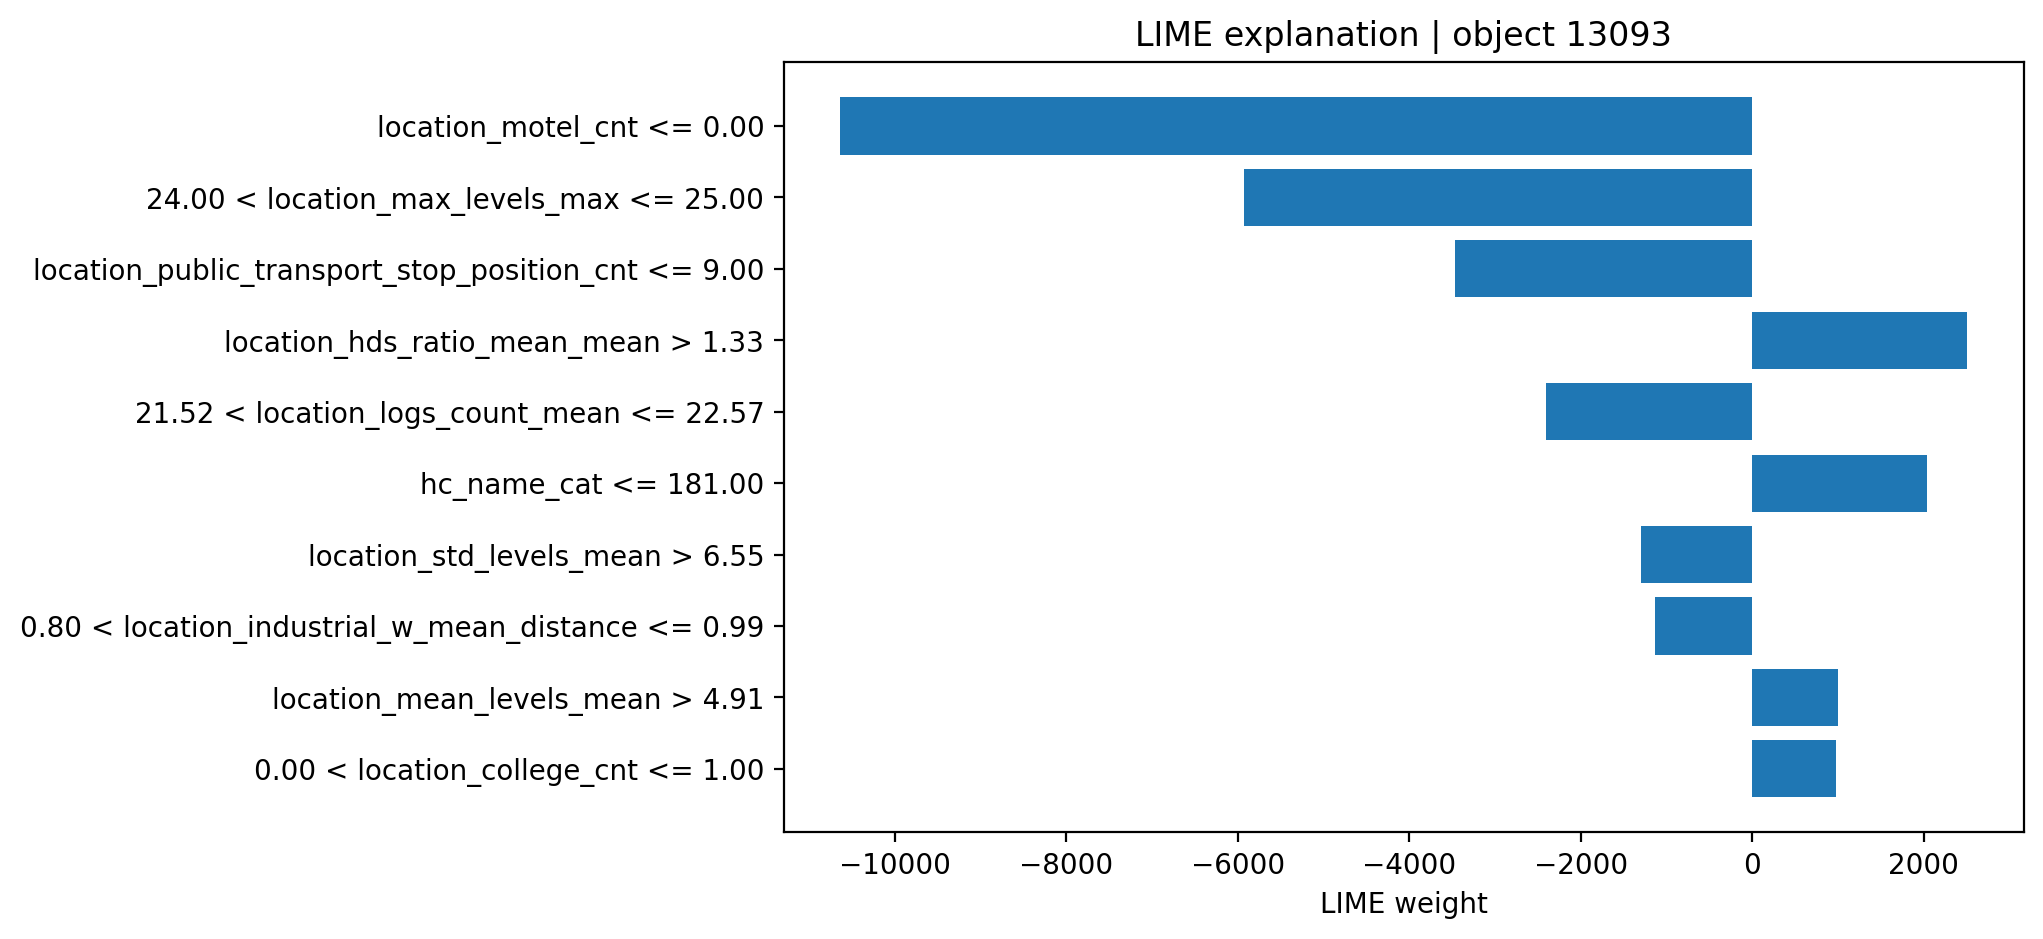

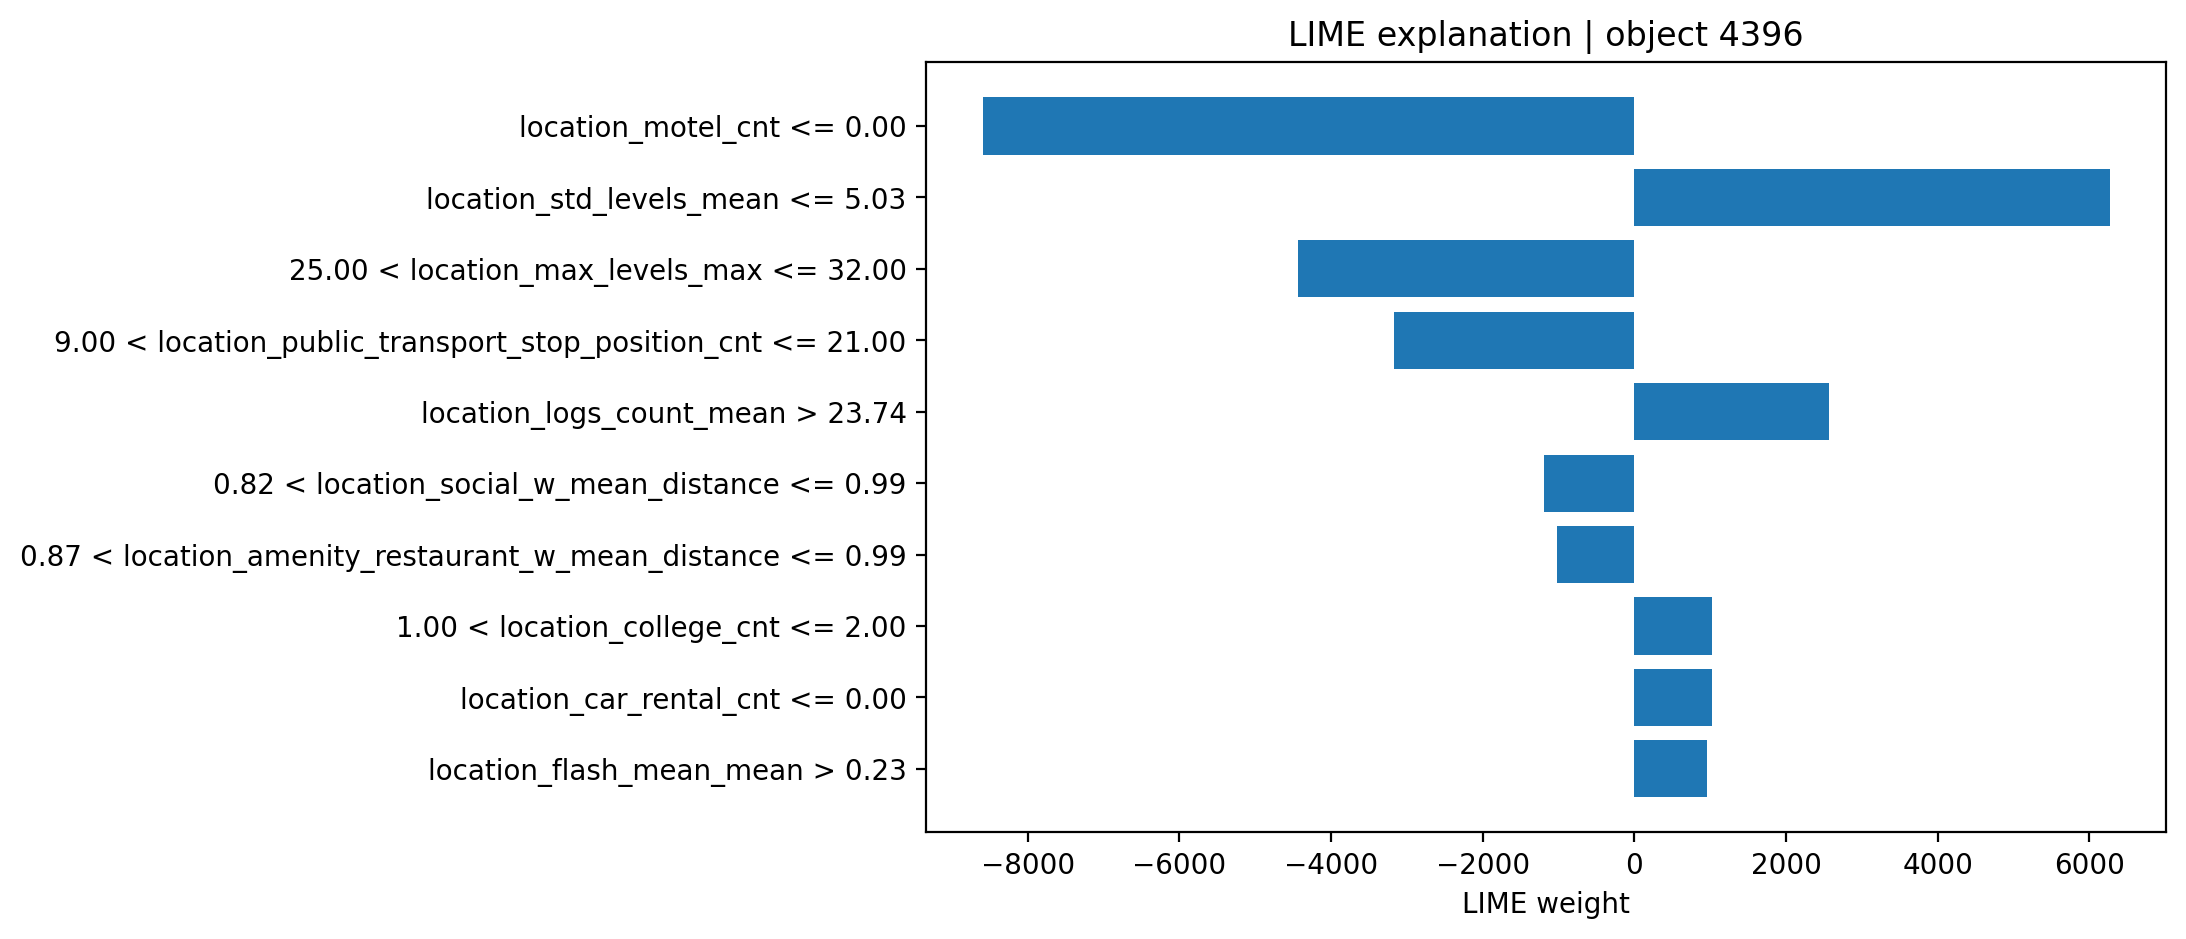

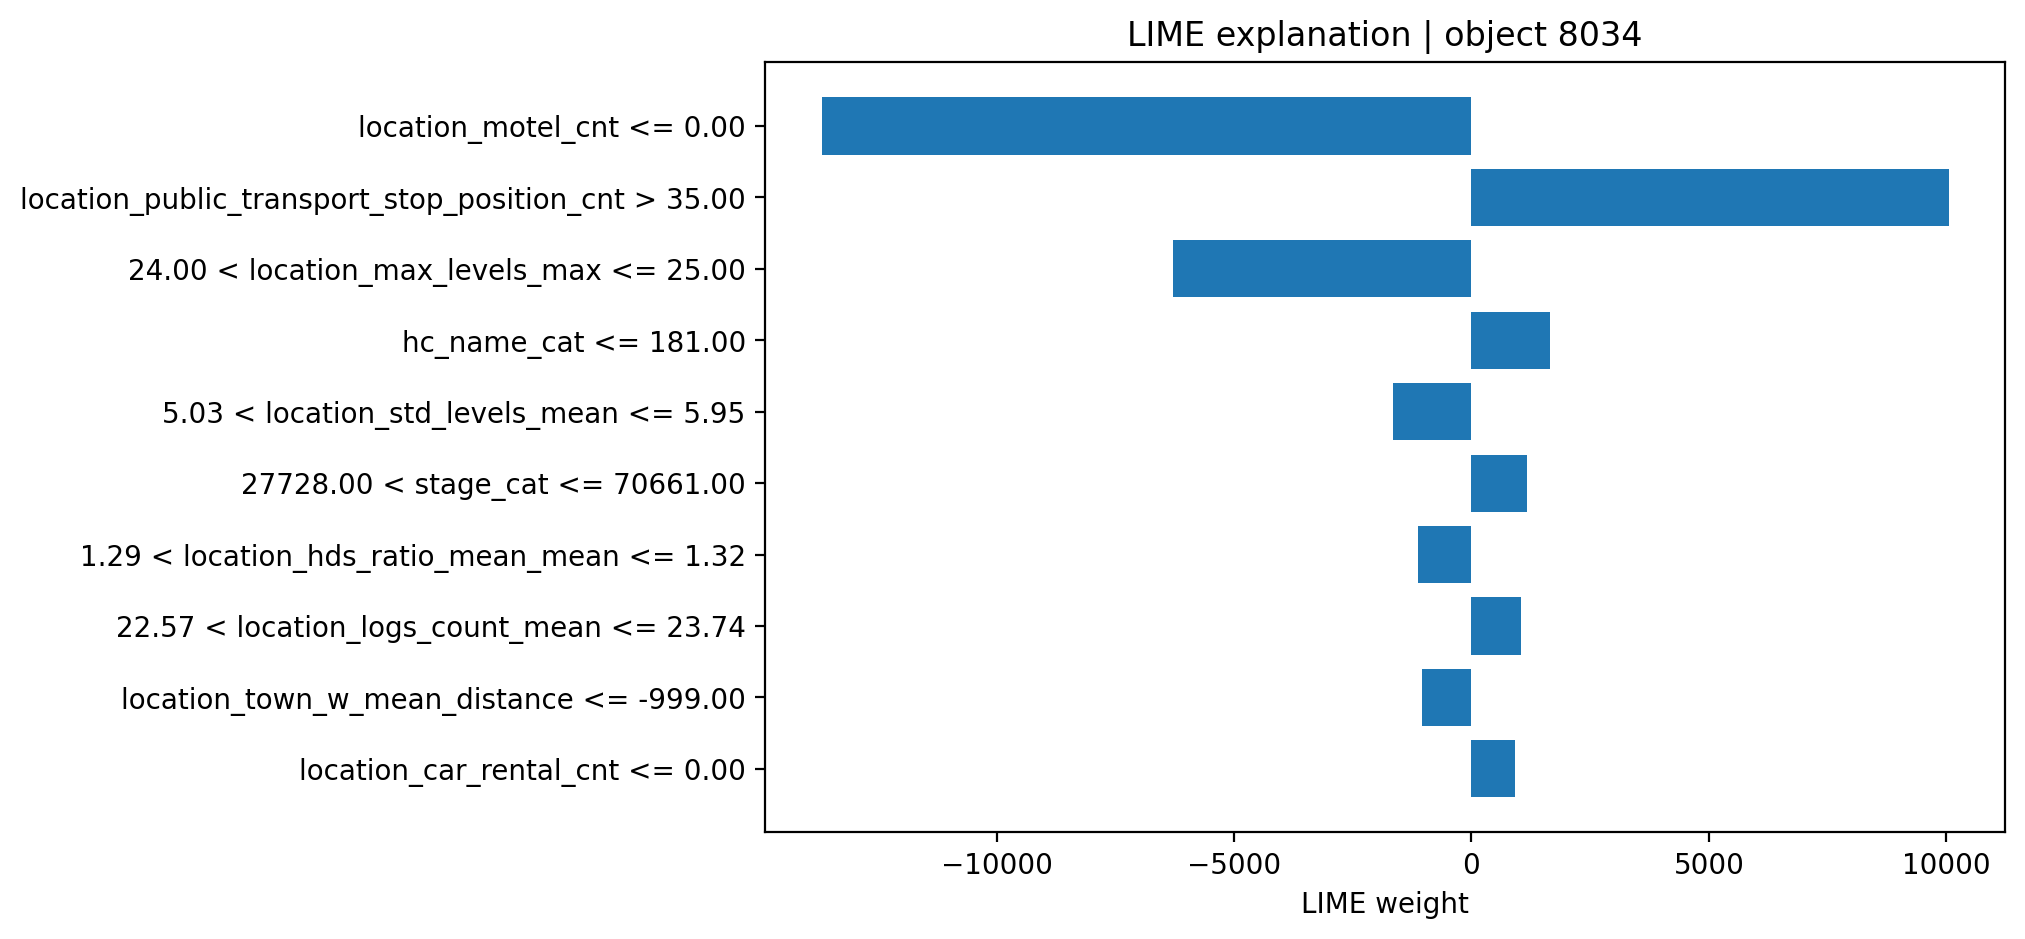


num_samples=500
                                             feature       weight
0           24.00 < location_max_levels_max <= 25.00 -8339.585984
1  location_public_transport_stop_position_cnt <=... -5929.454124
2                         location_motel_cnt <= 0.00  5239.146604
3            location_social_w_mean_distance <= 0.68  4821.578647
4                location_hds_ratio_mean_mean > 1.33  3638.794382
5           location_barrier_w_mean_distance <= 0.82  3582.694671
6                    location_std_levels_mean > 6.55 -3482.996855
7  0.67 < location_amenity_restaurant_w_mean_dist... -3287.156576
8  0.87 < location_shop_product_w_mean_distance <... -2928.141754
9    0.90 < location_leisure_w_mean_distance <= 0.95  1991.950363

num_samples=1000
                                             feature       weight
0                         location_motel_cnt <= 0.00 -8163.847711
1           24.00 < location_max_levels_max <= 25.00 -6523.080676
2  location_public_transport_stop_positio

In [61]:
num_cols = list(numeric_features)
X_train_num = X_train[num_cols].copy()
X_test_num = X_test[num_cols].copy()

preprocessor_num = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols)
], remainder='drop')

pipe_gbr_num = Pipeline([
    ('prep', preprocessor_num),
    ('model', GradientBoostingRegressor(max_depth=5, random_state=42))
])

pipe_gbr_num.fit(X_train_num, y_train)

explainer = LimeTabularExplainer(
    training_data=X_train_num.values,
    feature_names=num_cols,
    mode='regression',
    discretize_continuous=True,
    random_state=42
)

example_ids = X_test_num.sample(3, random_state=42).index.tolist()
example_ids

lime_results = {}

for idx in example_ids:
    x0 = X_test_num.loc[idx].values
    
    exp = explainer.explain_instance(
        data_row=x0,
        predict_fn=lambda x: pipe_gbr_num.predict(pd.DataFrame(x, columns=num_cols)),
        num_features=10,
        num_samples=5000
    )
    
    lime_results[idx] = exp
    
    print(f"\n=== Object {idx} ===")
    print("Prediction:", pipe_gbr_num.predict(X_test_num.loc[[idx]])[0])
    print(exp.as_list())

def plot_lime_exp(exp, title):
    items = exp.as_list()
    feats = [x[0] for x in items]
    vals = [x[1] for x in items]

    plt.figure(figsize=(8, 5))
    plt.barh(range(len(feats)), vals)
    plt.yticks(range(len(feats)), feats)
    plt.title(title)
    plt.xlabel("LIME weight")
    plt.gca().invert_yaxis()
    plt.show()

for idx in example_ids:
    plot_lime_exp(lime_results[idx], f"LIME explanation | object {idx}")

sample_grid = [500, 1000, 3000, 5000, 10000]
idx = example_ids[0]
x0 = X_test_num.loc[idx].values

sample_results = {}

for n in sample_grid:
    exp = explainer.explain_instance(
        data_row=x0,
        predict_fn=lambda x: pipe_gbr_num.predict(pd.DataFrame(x, columns=num_cols)),
        num_features=10,
        num_samples=n
    )
    sample_results[n] = pd.DataFrame(exp.as_list(), columns=['feature', 'weight'])
    print(f"\nnum_samples={n}")
    print(sample_results[n])

In [62]:
all_weights = []

for n, df in sample_results.items():
    tmp = df.copy()
    tmp['num_samples'] = n
    all_weights.append(tmp)

weights_df = pd.concat(all_weights, ignore_index=True)

pivot_weights = weights_df.pivot_table(
    index='feature',
    columns='num_samples',
    values='weight'
)

print(pivot_weights)

num_samples                                               500          1000   \
feature                                                                        
0.67 < location_amenity_restaurant_w_mean_dista... -3287.156576          NaN   
0.87 < location_shop_product_w_mean_distance <=... -2928.141754          NaN   
0.88 < location_office_w_mean_distance <= 0.99              NaN          NaN   
0.90 < location_leisure_w_mean_distance <= 0.95     1991.950363          NaN   
0.91 < location_marketplace_w_mean_distance <= ...          NaN -2120.707502   
21.52 < location_logs_count_mean <= 22.57                   NaN -2203.605386   
22.39 < location_logs_count_std <= 24.49                    NaN          NaN   
24.00 < location_max_levels_max <= 25.00           -8339.585984 -6523.080676   
floor > 13.00                                               NaN  1930.264553   
hc_name_cat <= 181.00                                       NaN          NaN   
location_amenity_leisure_w_mean_distance

In [64]:
kernel_widths = [0.25, 0.75, 1.5, 3.0]
idx = example_ids[0]
x0 = X_test_num.loc[idx].values

kernel_results = {}

for kw in kernel_widths:
    explainer_kw = LimeTabularExplainer(
        training_data=X_train_num.values,
        feature_names=num_cols,
        mode='regression',
        discretize_continuous=True,
        random_state=42,
        kernel_width=kw
    )
    
    exp = explainer_kw.explain_instance(
        data_row=x0,
        predict_fn=lambda x: pipe_gbr_num.predict(pd.DataFrame(x, columns=num_cols)),
        num_features=10,
        num_samples=5000
    )
    
    kernel_results[kw] = pd.DataFrame(exp.as_list(), columns=['feature', 'weight'])
    
    print(f"\n=== kernel_width={kw} ===")
    print(kernel_results[kw])


=== kernel_width=0.25 ===
                                             feature         weight
0                        location_natural_cnt > 1.00 -3.346905e-122
1  0.88 < location_highway_crossing_w_mean_distan... -3.346905e-122
2  0.86 < location_residential_w_mean_distance <=... -3.346905e-122
3               1.00 < location_pop_cafe_cnt <= 2.00 -3.346905e-122
4  17.00 < location_highway_traffic_signals_cnt <... -3.346905e-122
5                              hc_name_cat <= 181.00 -3.346905e-122
6    0.90 < location_leisure_w_mean_distance <= 0.95 -3.346905e-122
7             0.00 < location_commercial_cnt <= 1.00 -3.346905e-122
8            location_railway_w_mean_distance > 1.03 -3.346905e-122
9                      location_leisure_cnt > 164.00 -3.346905e-122

=== kernel_width=0.75 ===
                                             feature        weight
0                        location_natural_cnt > 1.00 -4.639032e-10
1             0.00 < location_commercial_cnt <= 1.00 -4.383557e-

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


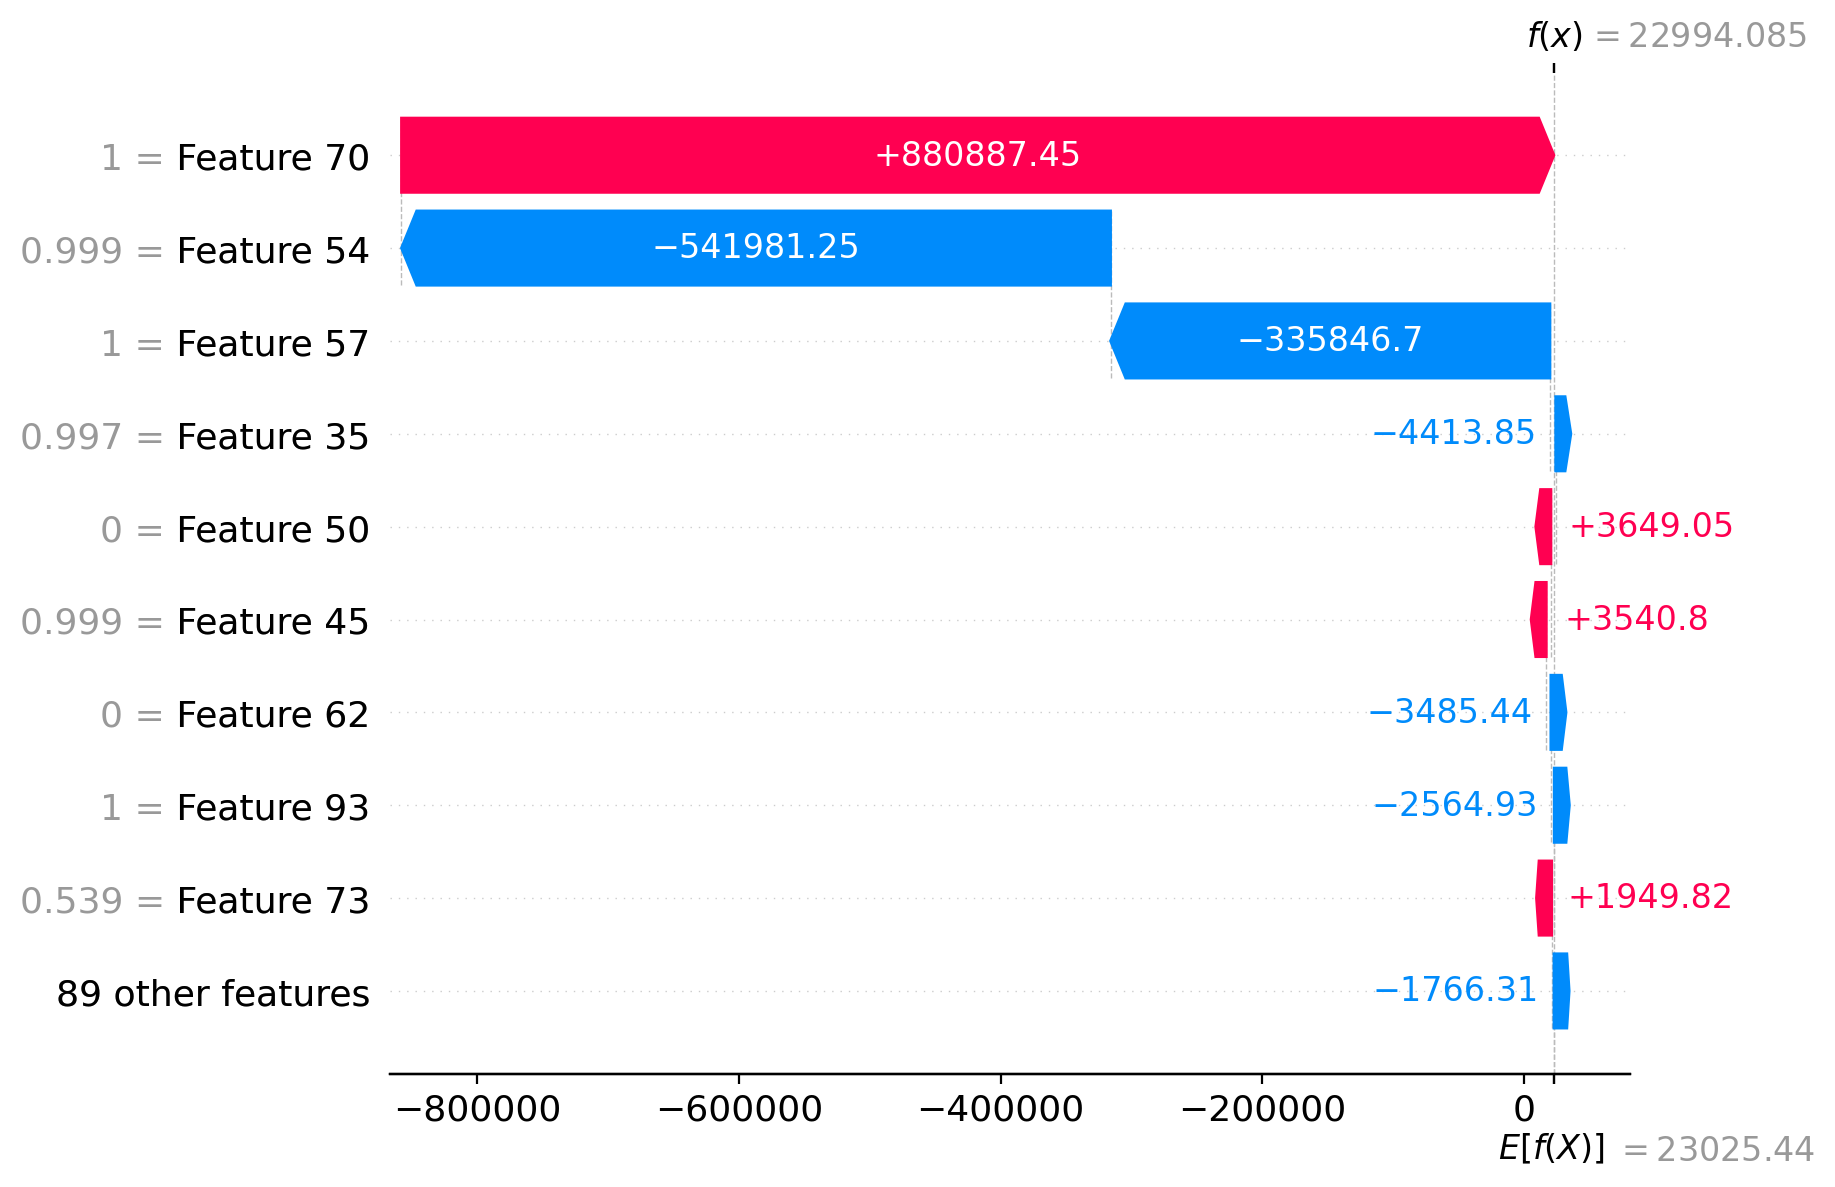

In [70]:
import shap

feature_names = get_feature_names(preprocessor_minmax)

X_train_tr = preprocessor_minmax.fit_transform(X_train)
X_test_tr = preprocessor_minmax.transform(X_test)

linear_model = pipe_linear.named_steps['model']
gbr_model = pipe_gbr.named_steps['model']

idx = X_test.index[8]
row_num = list(X_test.index).index(idx)
x_one = X_test_tr[row_num:row_num+1]

explainer_linear = shap.LinearExplainer(linear_model, X_train_tr)
shap_values_linear = explainer_linear(x_one)

# shap_values_linear.feature_names = feature_names
shap.plots.waterfall(shap_values_linear[0])

In [71]:
pred_linear = linear_model.predict(x_one)[0]
shap_sum_linear = shap_values_linear.base_values[0] + shap_values_linear.values[0].sum()

print("Linear prediction:", pred_linear)
print("Linear SHAP sum:", shap_sum_linear)

Linear prediction: 22994.08533624839
Linear SHAP sum: 22994.0853362482


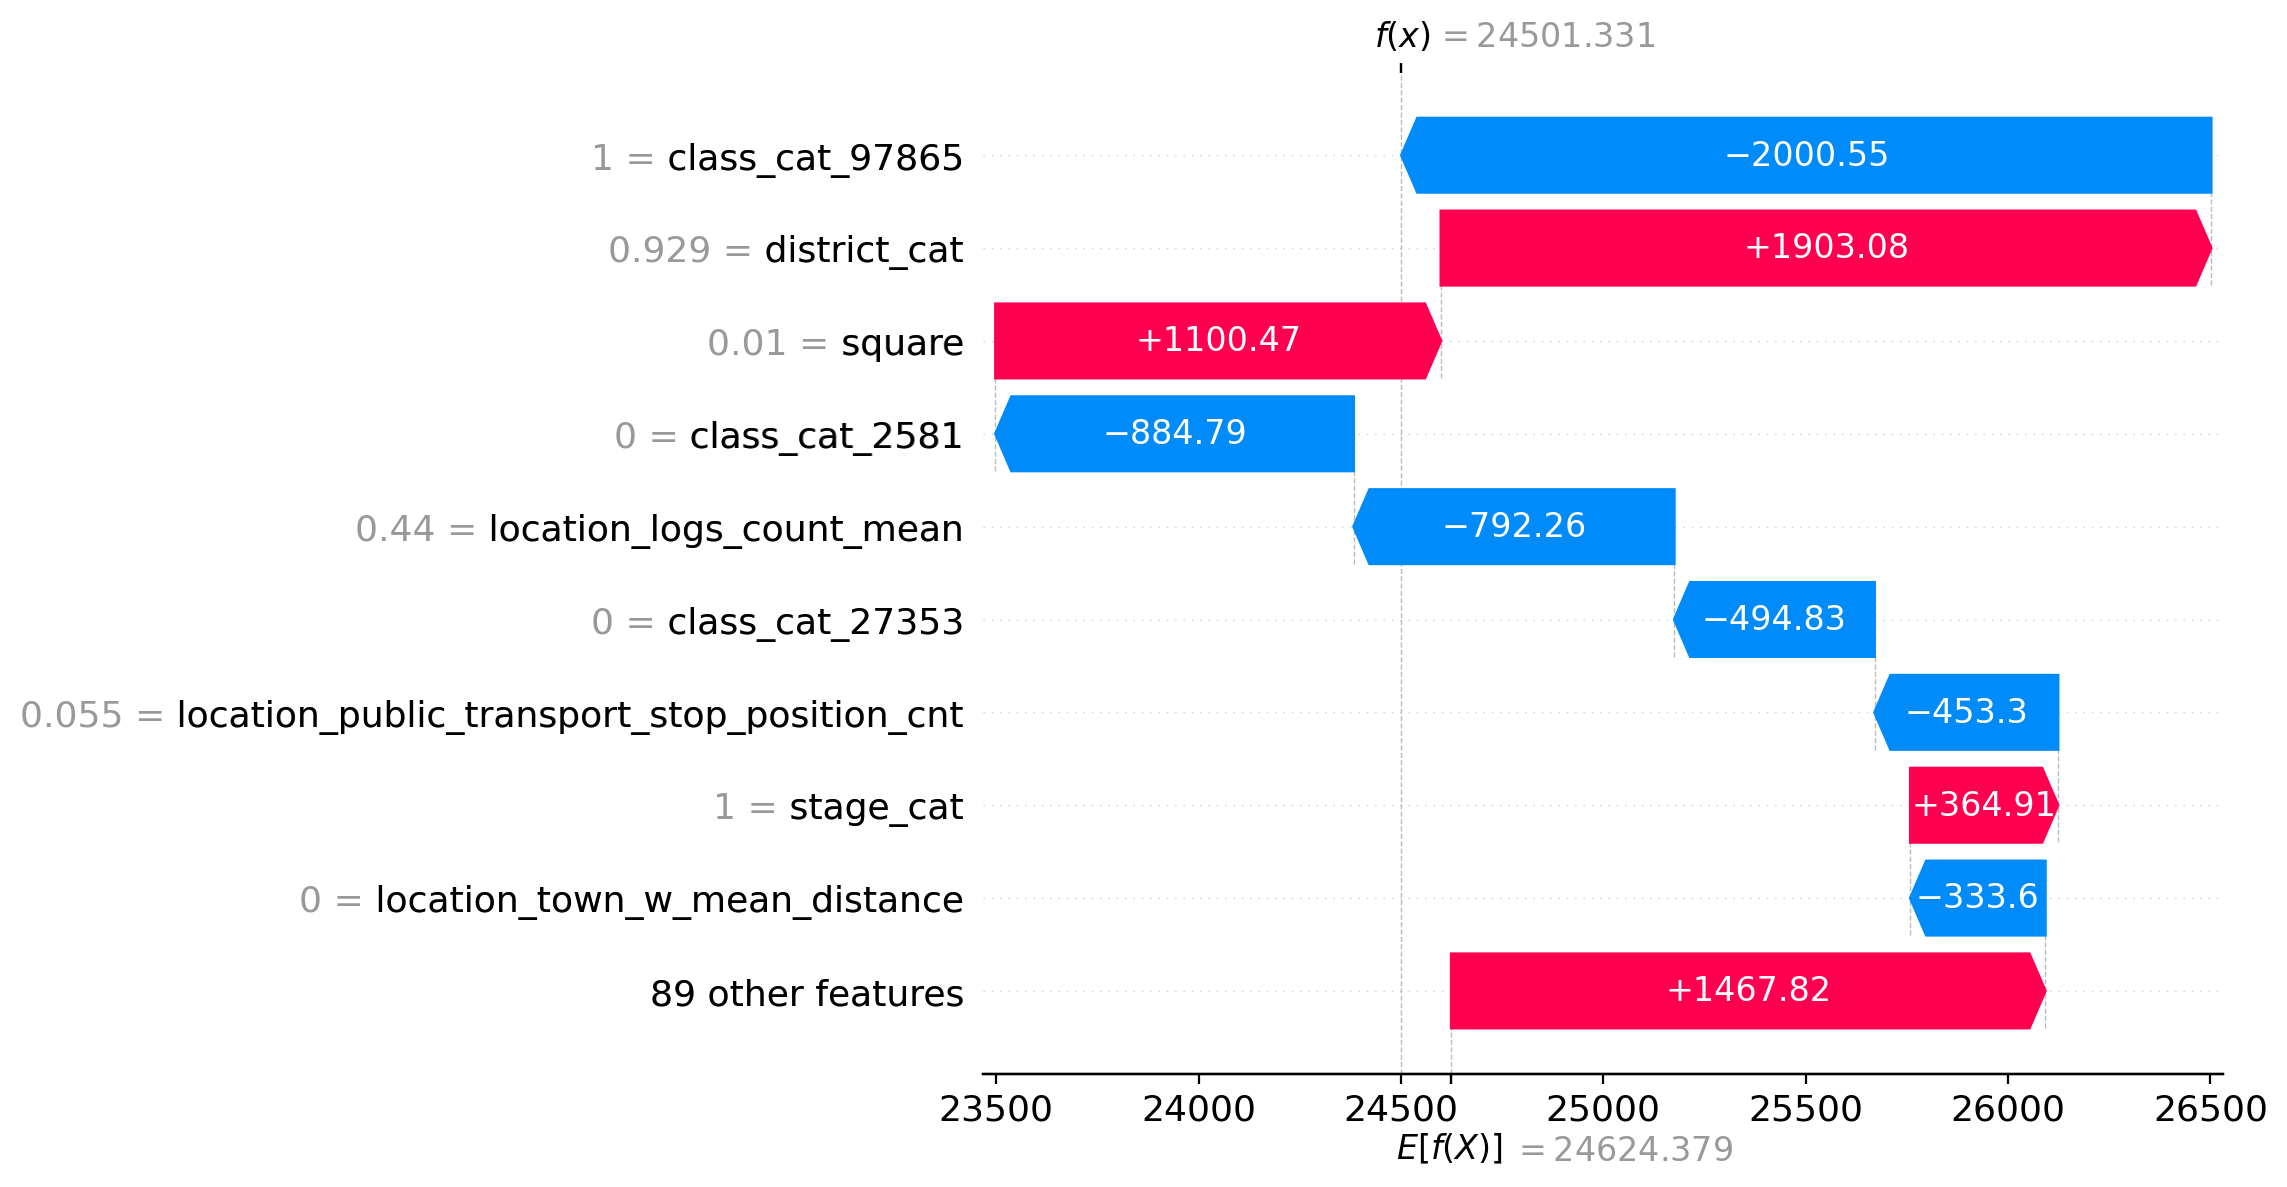

In [72]:
explainer_gbr = shap.TreeExplainer(gbr_model)
shap_values_gbr = explainer_gbr(x_one)

shap_values_gbr.feature_names = feature_names
shap.plots.waterfall(shap_values_gbr[0])

In [73]:
pred_gbr = gbr_model.predict(x_one)[0]
shap_sum_gbr = shap_values_gbr.base_values[0] + shap_values_gbr.values[0].sum()

print("GBR prediction:", pred_gbr)
print("GBR SHAP sum:", shap_sum_gbr)

GBR prediction: 24501.330632798312
GBR SHAP sum: 24501.33063279832


У линейной модели признаки пытаются компенсировать друг друга большими кожфф. У дерева с этим все нормик